# EEG_08 — Clustering dei Soggetti da Caratteristiche del Segnale

**Approccio data-first (Francesco)**:
1. Estrai feature dal segnale EEG grezzo per soggetto (potenza per banda, connettività PCC, metriche grafo)
2. Clustering dei soggetti nello spazio feature (K-means + gerarchico)
3. **Solo dopo**: confronto con le performance dei modelli (EEG_06 results)

Obiettivo: capire se i soggetti hanno caratteristiche EEG sistematicamente diverse
e se questi gruppi si riflettono nelle performance dei modelli.

---
**Reference**: Iacomi et al. 2026 — gamma dominanza, 3 pathways stabili (stesso dataset)  
**Env**: `daniele_311` (Python 3.11)

In [1]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

# Bande di frequenza da analizzare (Hz)
FREQ_BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 60),   # Iacomi 2026: banda più informativa per IS
}

FS = 256          # frequenza di campionamento (Hz)
N_SAMPLES = 384   # campioni per trial (~1.5s)
N_CHANS   = 61    # canali EEG nel file H5 / CSV

# Numero massimo di trial per soggetto per l'analisi (None = tutti)
MAX_TRIALS_PER_SUBJ = None

# K per grafo PCC k-NN (usato per metriche di grafo)
K_GRAPH = 6

# Numero di componenti PCA da mantenere prima di UMAP / clustering
N_PCA_COMPONENTS = 20

# Clustering: range di k per K-means
K_RANGE = [2, 3, 4, 5]

# Seed riproducibilità
RANDOM_STATE = 42

# Percorso CSV risultati EEG_06
EEG06_RESULTS_CSV = "data/interim/eeg_06_ss_norm_results.csv"

print("Config OK")

In [2]:
# ============================================================
# IMPORT E PATHS
# ============================================================

import os, sys, json, warnings
warnings.filterwarnings("ignore")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict

from scipy import signal as scipy_signal
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import f_oneway, kruskal

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("⚠️  umap-learn non installato — skip UMAP, solo PCA.")
    print("   Installa con: pip install umap-learn")

# ---- Project root ----
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)
sys.path.insert(0, str(project_root / "scripts"))

# ---- Paths ----
CSV_ROOT    = project_root / "data" / "raw_csv" / "training_set"
INTERIM_DIR = project_root / "data" / "interim"
FIGURES_DIR = project_root / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---- Canali ----
_eloc_candidates = [
    INTERIM_DIR / "ebneuro.csv",
    Path("/mnt/c/Users/students/Desktop/Paolo/LM_Thesis/ebneuro.csv"),
]
CH_NAMES = [str(i) for i in range(N_CHANS)]
for _p in _eloc_candidates:
    if _p.exists():
        CH_NAMES = pd.read_csv(_p, sep=";", decimal=",")["labels"].tolist()[:N_CHANS]
        print(f"Canali caricati da: {_p.name}")
        break

print(f"Project root : {project_root}")
print(f"CSV root     : {CSV_ROOT}")
print(f"N canali     : {N_CHANS}")

Canali caricati da: ebneuro.csv
Project root : /home/daniele_u/miralis-hypergraph-imagined-speech
CSV root     : /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set
N canali     : 61


In [3]:
# ============================================================
# CARICAMENTO TRIAL E ESTRAZIONE FEATURE PER SOGGETTO
# ============================================================
# Feature estratte per ogni soggetto (media su tutti i trial del soggetto):
#   - Potenza relativa per banda (δ, θ, α, β, γ) × N_CHANS
#   - Matrice PCC media (N_CHANS × N_CHANS) → vettore triangolo superiore
#   - Metriche grafo: grado medio, clustering coefficient medio, densità
# ============================================================

def load_csv_trial(csv_path: Path) -> np.ndarray:
    """Legge CSV 61×384 senza header. Restituisce float32 (61, 384)."""
    return pd.read_csv(csv_path, header=None).values.astype(np.float32)


def band_power_per_channel(x_np: np.ndarray, fs: int, bands: dict) -> np.ndarray:
    """
    Potenza relativa per banda via Welch per ogni canale.

    Args:
        x_np  : (N_CHANS, N_SAMPLES)
        fs    : frequenza campionamento
        bands : dict {nome: (f_low, f_high)}

    Returns:
        feat: (N_CHANS, N_BANDS) — potenza relativa
    """
    freqs, psd = scipy_signal.welch(x_np, fs=fs, nperseg=min(128, x_np.shape[1]))
    # psd shape: (N_CHANS, n_freqs)
    total_power = psd.sum(axis=1, keepdims=True) + 1e-12
    feat = []
    for (f_lo, f_hi) in bands.values():
        mask = (freqs >= f_lo) & (freqs < f_hi)
        band_p = psd[:, mask].sum(axis=1) / total_power[:, 0]
        feat.append(band_p)
    return np.stack(feat, axis=1)  # (N_CHANS, N_BANDS)


def pcc_matrix(x_np: np.ndarray) -> np.ndarray:
    """Pearson |PCC| tra canali. Shape: (N, N)."""
    pcc = np.abs(np.corrcoef(x_np))
    np.fill_diagonal(pcc, 0.0)
    return pcc


def graph_metrics_from_pcc(pcc: np.ndarray, k: int) -> dict:
    """
    Metriche scalari da grafo k-NN PCC:
      - mean_degree       : grado medio
      - density           : densità del grafo
      - mean_clustering   : coefficiente clustering medio
      - mean_strength     : forza media (somma pesi vicini)
    """
    N = pcc.shape[0]
    # k-NN adjacency
    adj = np.zeros((N, N))
    for i in range(N):
        row = pcc[i].copy(); row[i] = -1.0
        top_k = np.argsort(row)[-k:]
        adj[i, top_k] = pcc[i, top_k]
        adj[top_k, i] = pcc[top_k, i]

    # Grado (binarizzato)
    adj_bin  = (adj > 0).astype(float)
    degrees  = adj_bin.sum(axis=1)
    # Densità
    density = adj_bin.sum() / (N * (N - 1))
    # Coefficiente clustering (formula pesata semplificata)
    cc = []
    for i in range(N):
        nbrs = np.where(adj_bin[i] > 0)[0]
        ki = len(nbrs)
        if ki < 2:
            cc.append(0.0)
            continue
        triangles = sum(
            adj_bin[u, v]
            for idx_u, u in enumerate(nbrs)
            for v in nbrs[idx_u+1:]
        )
        cc.append(2 * triangles / (ki * (ki - 1)))
    # Forza media (pesi)
    strength = adj.sum(axis=1)

    return {
        "mean_degree":     float(degrees.mean()),
        "density":         float(density),
        "mean_clustering": float(np.mean(cc)),
        "mean_strength":   float(strength.mean()),
    }


# ---- Scansione cartelle ----
session_dirs = sorted(CSV_ROOT.iterdir())
subjects_all = sorted(set(d.name.split("_")[0] for d in session_dirs if d.is_dir()))
print(f"Soggetti trovati: {len(subjects_all)}")
print(f"Sessioni totali : {len(session_dirs)}")
print(f"Feature per soggetto:")
n_bands  = len(FREQ_BANDS)
n_triu   = N_CHANS * (N_CHANS - 1) // 2
n_graph  = 4  # mean_degree, density, mean_clustering, mean_strength
n_feat_total = N_CHANS * n_bands + n_triu + n_graph
print(f"  Potenza per banda : {N_CHANS} canali × {n_bands} bande = {N_CHANS*n_bands}")
print(f"  PCC triangolo sup : {n_triu}")
print(f"  Metriche grafo    : {n_graph}")
print(f"  TOTALE            : {n_feat_total}")

Soggetti trovati: 74
Sessioni totali : 357
Feature per soggetto:
  Potenza per banda : 61 canali × 5 bande = 305
  PCC triangolo sup : 1830
  Metriche grafo    : 4
  TOTALE            : 2139


In [4]:
# ============================================================
# ESTRAZIONE FEATURE: itera tutti i soggetti
# Salva/carica cache in data/interim/subject_features.npz
# ============================================================

CACHE_PATH = INTERIM_DIR / "subject_features.npz"
FORCE_RECOMPUTE = False   # True = ricalcola anche se cache esiste

if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    print(f"Carico da cache: {CACHE_PATH}")
    data = np.load(CACHE_PATH, allow_pickle=True)
    subject_ids  = list(data["subject_ids"])
    X_subjects   = data["X_subjects"]       # (N_subj, n_feat)
    feat_names   = list(data["feat_names"])
    n_trials_per = dict(zip(data["subject_ids"], data["n_trials_per"]))
    # Band power matrix: (N_subj, N_CHANS, N_BANDS)
    band_power_mat = data["band_power_mat"]
    # PCC medio per soggetto: (N_subj, N_CHANS, N_CHANS)
    pcc_mean_mat = data["pcc_mean_mat"]
    print(f"  Soggetti : {len(subject_ids)}")
    print(f"  Feature  : {X_subjects.shape[1]}")
else:
    print("Estrazione feature per soggetto...")

    subject_ids     = []
    X_list          = []         # lista righe feature
    band_power_list = []         # (N_CHANS, N_BANDS) medi
    pcc_mean_list   = []         # (N_CHANS, N_CHANS) medi
    n_trials_per    = {}

    for subj in tqdm(subjects_all, desc="Soggetti"):
        # Raccogli tutti i trial del soggetto
        bp_accum  = []    # band power accumulatore
        pcc_accum = []    # PCC accumulatore
        g_metrics = defaultdict(list)

        subj_dirs = sorted(d for d in session_dirs if d.name.startswith(subj + "_"))
        trial_count = 0

        for sess_dir in subj_dirs:
            csv_files = sorted(sess_dir.glob("*.csv"))
            for csv_path in csv_files:
                if MAX_TRIALS_PER_SUBJ and trial_count >= MAX_TRIALS_PER_SUBJ:
                    break
                x = load_csv_trial(csv_path)       # (61, 384)
                if x.shape != (N_CHANS, N_SAMPLES):
                    continue
                # Band power
                bp = band_power_per_channel(x, FS, FREQ_BANDS)  # (61, 5)
                bp_accum.append(bp)
                # PCC
                pcc = pcc_matrix(x)    # (61, 61)
                pcc_accum.append(pcc)
                # Graph metrics
                gm = graph_metrics_from_pcc(pcc, k=K_GRAPH)
                for k_m, v_m in gm.items():
                    g_metrics[k_m].append(v_m)
                trial_count += 1

        if trial_count == 0:
            continue

        n_trials_per[subj] = trial_count

        # Medie sul soggetto
        bp_mean  = np.mean(bp_accum,  axis=0)   # (61, 5)
        pcc_mean = np.mean(pcc_accum, axis=0)   # (61, 61)

        # ---- Costruisci vettore feature ----
        # 1. Band power flattened: (61*5,) = 305
        feat_bp   = bp_mean.flatten()
        # 2. PCC triangolo superiore: N_CHANS*(N_CHANS-1)/2 = 1830
        feat_pcc  = pcc_mean[np.triu_indices(N_CHANS, k=1)]
        # 3. Graph metrics scalari: 4
        feat_gm   = np.array([np.mean(g_metrics[k_m]) for k_m in
                               ["mean_degree", "density", "mean_clustering", "mean_strength"]])

        X_list.append(np.concatenate([feat_bp, feat_pcc, feat_gm]))
        subject_ids.append(subj)
        band_power_list.append(bp_mean)
        pcc_mean_list.append(pcc_mean)

    X_subjects     = np.array(X_list)          # (N_subj, n_feat)
    band_power_mat = np.array(band_power_list) # (N_subj, N_CHANS, N_BANDS)
    pcc_mean_mat   = np.array(pcc_mean_list)   # (N_subj, N_CHANS, N_CHANS)

    # Nomi feature
    band_names = list(FREQ_BANDS.keys())
    feat_names = (
        [f"bp_{b}_{ch}" for b in band_names for ch in range(N_CHANS)] +
        [f"pcc_{i}_{j}" for i, j in zip(*np.triu_indices(N_CHANS, k=1))] +
        ["mean_degree", "density", "mean_clustering", "mean_strength"]
    )

    # Salva cache
    INTERIM_DIR.mkdir(parents=True, exist_ok=True)
    np.savez(
        CACHE_PATH,
        subject_ids   = np.array(subject_ids),
        X_subjects    = X_subjects,
        feat_names    = np.array(feat_names),
        n_trials_per  = np.array([n_trials_per[s] for s in subject_ids]),
        band_power_mat= band_power_mat,
        pcc_mean_mat  = pcc_mean_mat,
    )
    print(f"\nSalvato in cache: {CACHE_PATH}")

print(f"\nSoggetti processati : {len(subject_ids)}")
print(f"Feature per soggetto: {X_subjects.shape[1]}")
print(f"Trial medi per sogg : {np.mean(list(n_trials_per.values())):.0f}")
print(f"Shape X_subjects    : {X_subjects.shape}")

Carico da cache: /home/daniele_u/miralis-hypergraph-imagined-speech/data/interim/subject_features.npz
  Soggetti : 74
  Feature  : 2139

Soggetti processati : 74
Feature per soggetto: 2139
Trial medi per sogg : 525
Shape X_subjects    : (74, 2139)


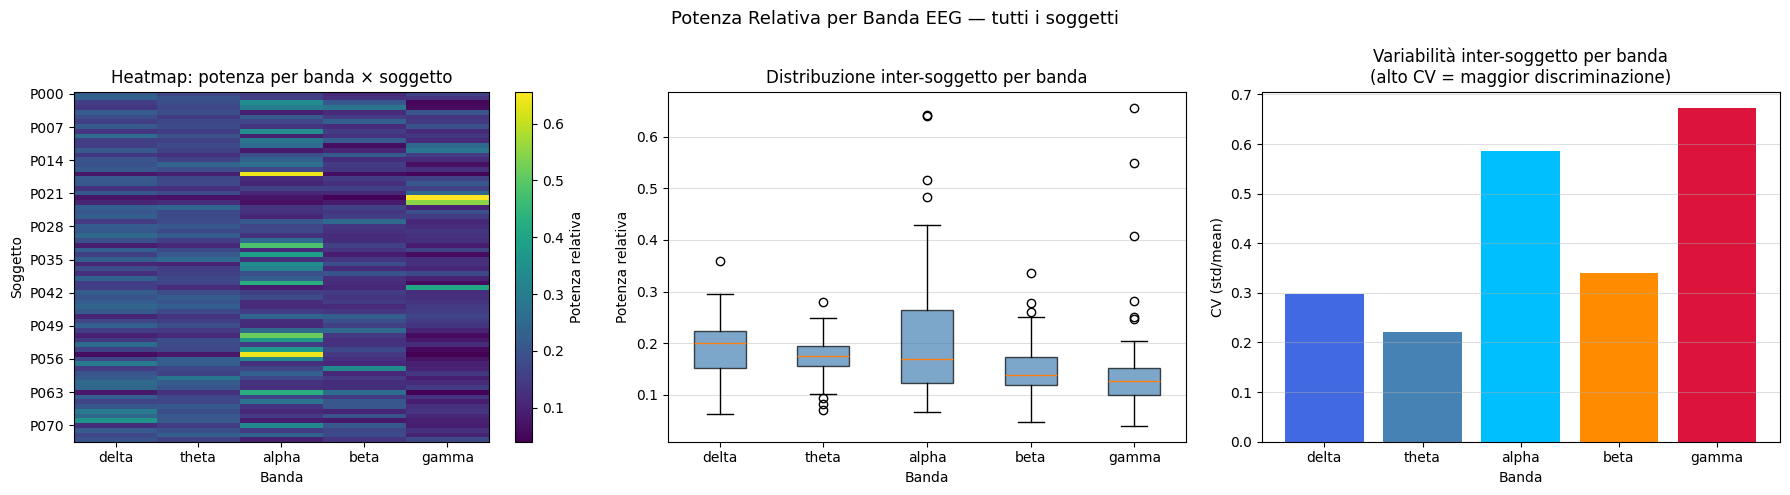


ANOVA / Kruskal-Wallis: varianza inter-banda (potenza media per soggetto)
  delta :  μ=0.1869  σ=0.0558  CV=0.299
  theta :  μ=0.1749  σ=0.0386  CV=0.221
  alpha :  μ=0.2128  σ=0.1248  CV=0.586
  beta  :  μ=0.1503  σ=0.0511  CV=0.340
  gamma :  μ=0.1425  σ=0.0958  CV=0.672

Kruskal-Wallis (differenza tra bande): p=0.0000


In [5]:
# ============================================================
# ANALISI POTENZA PER BANDA — panoramica tra soggetti
# Ispirati da Iacomi 2026: gamma è la banda più integrata per IS
# ============================================================

band_names = list(FREQ_BANDS.keys())
n_subj     = len(subject_ids)

# ---- 1. Potenza media per banda (media su canali e trial) ----
bp_mean_per_subj_band = band_power_mat.mean(axis=1)  # (N_subj, N_BANDS)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Potenza Relativa per Banda EEG — tutti i soggetti", fontsize=13)

# Heatmap soggetti × bande
im0 = axes[0].imshow(bp_mean_per_subj_band, aspect="auto", cmap="viridis")
axes[0].set_xticks(range(len(band_names))); axes[0].set_xticklabels(band_names)
axes[0].set_yticks(range(0, n_subj, max(1, n_subj // 10)))
axes[0].set_yticklabels([subject_ids[i] for i in range(0, n_subj, max(1, n_subj // 10))])
axes[0].set_xlabel("Banda"); axes[0].set_ylabel("Soggetto")
axes[0].set_title("Heatmap: potenza per banda × soggetto")
plt.colorbar(im0, ax=axes[0], label="Potenza relativa")

# Boxplot per banda (distribuzione tra soggetti)
axes[1].boxplot(bp_mean_per_subj_band, labels=band_names, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_xlabel("Banda"); axes[1].set_ylabel("Potenza relativa")
axes[1].set_title("Distribuzione inter-soggetto per banda")
axes[1].grid(axis="y", alpha=0.4)

# Coefficiente di variazione (CV) per banda: quanto variano i soggetti?
cv_per_band = bp_mean_per_subj_band.std(axis=0) / (bp_mean_per_subj_band.mean(axis=0) + 1e-9)
axes[2].bar(band_names, cv_per_band, color=["royalblue", "steelblue", "deepskyblue", "darkorange", "crimson"])
axes[2].set_xlabel("Banda"); axes[2].set_ylabel("CV (std/mean)")
axes[2].set_title("Variabilità inter-soggetto per banda\n(alto CV = maggior discriminazione)")
axes[2].grid(axis="y", alpha=0.4)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_band_power_overview.png", dpi=120, bbox_inches="tight")
plt.show()

# Test ANOVA: varianza inter-soggetto per banda
print("\nANOVA / Kruskal-Wallis: varianza inter-banda (potenza media per soggetto)")
for b_idx, b_name in enumerate(band_names):
    vals = bp_mean_per_subj_band[:, b_idx]
    print(f"  {b_name:6s}:  μ={vals.mean():.4f}  σ={vals.std():.4f}  CV={cv_per_band[b_idx]:.3f}")

_, p_kw = kruskal(*[bp_mean_per_subj_band[:, i] for i in range(len(band_names))])
print(f"\nKruskal-Wallis (differenza tra bande): p={p_kw:.4f}")

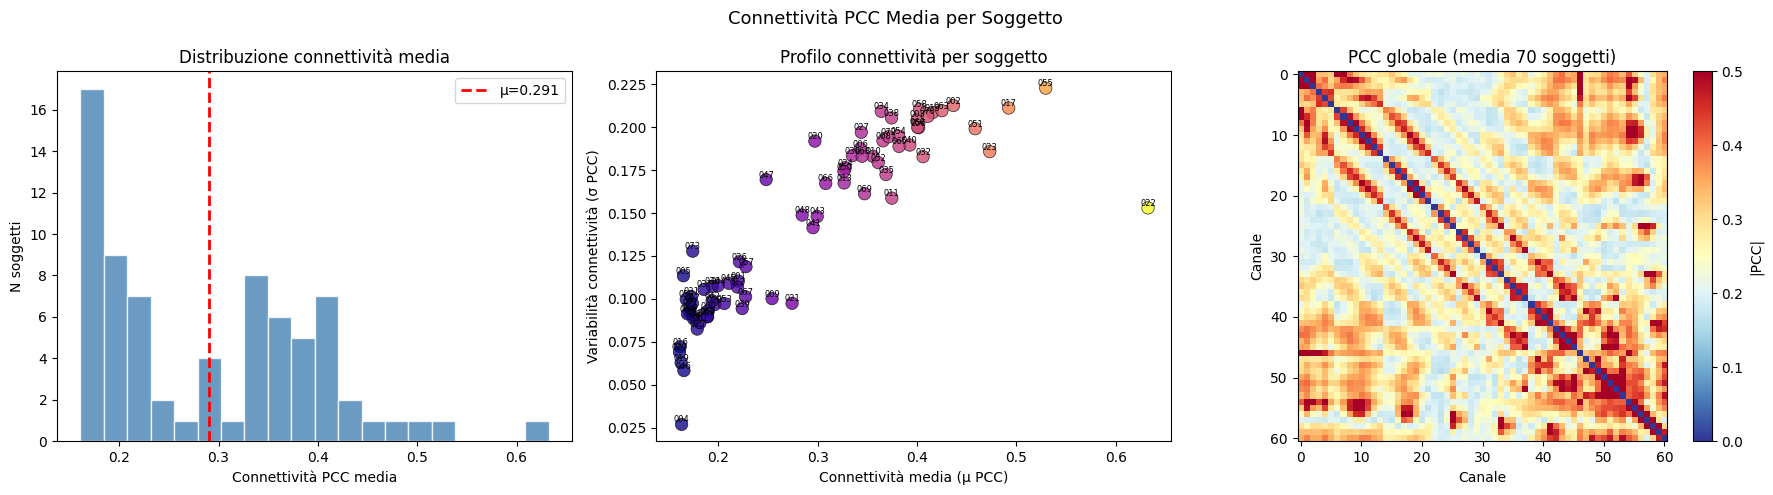

Connettività media globale: μ=0.2909  σ=0.1084
Soggetti ad alta connettività (>μ+σ): 14
Soggetti a bassa connettività (<μ-σ): 17


In [6]:
# ============================================================
# ANALISI PCC MEDIO — connettività media per soggetto
# ============================================================

# PCC medio per soggetto già in pcc_mean_mat: (N_subj, N_CHANS, N_CHANS)
# Indice scalare: connettività totale media del soggetto
mean_connectivity = np.array([
    pcc_mean_mat[i][np.triu_indices(N_CHANS, k=1)].mean()
    for i in range(n_subj)
])
# Deviazione standard della connettività (variabilità intra-soggetto)
std_connectivity = np.array([
    pcc_mean_mat[i][np.triu_indices(N_CHANS, k=1)].std()
    for i in range(n_subj)
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Connettività PCC Media per Soggetto", fontsize=13)

# Distribuzione connettività media
axes[0].hist(mean_connectivity, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(mean_connectivity.mean(), color="red", ls="--", lw=2,
                label=f"μ={mean_connectivity.mean():.3f}")
axes[0].set_xlabel("Connettività PCC media"); axes[0].set_ylabel("N soggetti")
axes[0].set_title("Distribuzione connettività media")
axes[0].legend()

# Scatter: μ vs σ connettività
axes[1].scatter(mean_connectivity, std_connectivity,
                c=mean_connectivity, cmap="plasma", s=80, alpha=0.8, edgecolors="black", lw=0.5)
for i, sid in enumerate(subject_ids):
    axes[1].annotate(sid.replace("P", ""), (mean_connectivity[i], std_connectivity[i]),
                     fontsize=6, ha="center", va="bottom")
axes[1].set_xlabel("Connettività media (μ PCC)")
axes[1].set_ylabel("Variabilità connettività (σ PCC)")
axes[1].set_title("Profilo connettività per soggetto")

# PCC medio su tutti i soggetti
pcc_global = pcc_mean_mat.mean(axis=0)  # (N_CHANS, N_CHANS)
im2 = axes[2].imshow(pcc_global, cmap="RdYlBu_r", vmin=0, vmax=0.5)
axes[2].set_title("PCC globale (media 70 soggetti)")
axes[2].set_xlabel("Canale"); axes[2].set_ylabel("Canale")
plt.colorbar(im2, ax=axes[2], label="|PCC|")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_pcc_connectivity.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Connettività media globale: μ={mean_connectivity.mean():.4f}  σ={mean_connectivity.std():.4f}")
print(f"Soggetti ad alta connettività (>μ+σ): {(mean_connectivity > mean_connectivity.mean()+mean_connectivity.std()).sum()}")
print(f"Soggetti a bassa connettività (<μ-σ): {(mean_connectivity < mean_connectivity.mean()-mean_connectivity.std()).sum()}")

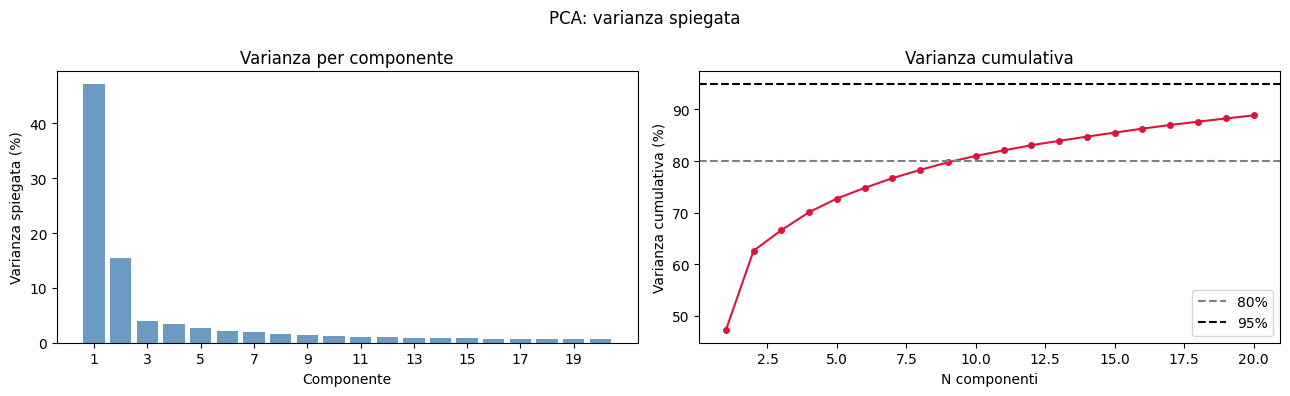

PC1+PC2 spiegano    : 62.6% della varianza
PC per 80% varianza : 10
PC per 95% varianza : 21


In [7]:
# ============================================================
# NORMALIZZAZIONE + PCA
# ============================================================

# Standardizzazione Z-score per feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subjects)  # (N_subj, n_feat)

# Gestione NaN / Inf (possibili se un soggetto ha pochi trial)
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# PCA
n_pca = min(N_PCA_COMPONENTS, X_scaled.shape[0] - 1, X_scaled.shape[1])
pca = PCA(n_components=n_pca, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)  # (N_subj, n_pca)

explained = pca.explained_variance_ratio_
cum_var   = explained.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("PCA: varianza spiegata", fontsize=12)

axes[0].bar(range(1, n_pca + 1), explained * 100, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Componente"); axes[0].set_ylabel("Varianza spiegata (%)")
axes[0].set_title("Varianza per componente")
axes[0].set_xticks(range(1, n_pca + 1, max(1, n_pca // 10)))

axes[1].plot(range(1, n_pca + 1), cum_var * 100, "o-", color="crimson", markersize=4)
axes[1].axhline(80, color="gray", ls="--", label="80%")
axes[1].axhline(95, color="black", ls="--", label="95%")
axes[1].set_xlabel("N componenti"); axes[1].set_ylabel("Varianza cumulativa (%)")
axes[1].set_title("Varianza cumulativa"); axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_pca_variance.png", dpi=120, bbox_inches="tight")
plt.show()

n_for_80  = int(np.searchsorted(cum_var, 0.80)) + 1
n_for_95  = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"PC1+PC2 spiegano    : {cum_var[1]*100:.1f}% della varianza")
print(f"PC per 80% varianza : {n_for_80}")
print(f"PC per 95% varianza : {n_for_95}")

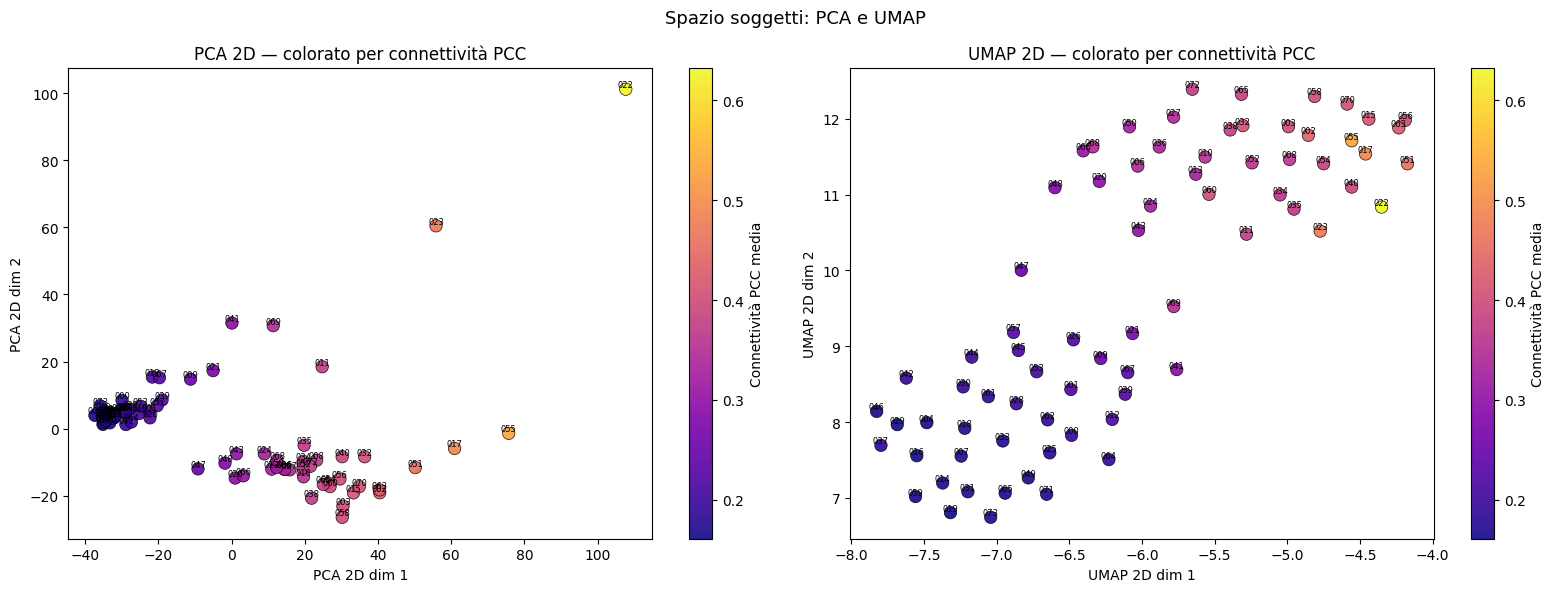

In [8]:
# ============================================================
# UMAP + PCA2D: visualizzazione nello spazio 2D
# ============================================================

# PCA a 2 componenti per visualizzazione
pca2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2d = pca2d.fit_transform(X_scaled)  # (N_subj, 2)

if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=min(15, n_subj - 1),
                        random_state=RANDOM_STATE, min_dist=0.1)
    X_umap = reducer.fit_transform(X_pca)  # applica UMAP su PCA
else:
    X_umap = None

# ---- Visualizzazione colorata per connettività media ----
n_plots = 2 if X_umap is not None else 1
fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 6))
if n_plots == 1:
    axes = [axes]
fig.suptitle("Spazio soggetti: PCA e UMAP", fontsize=13)

for ax, (proj, title) in zip(axes, [(X_pca2d, "PCA 2D"), (X_umap, "UMAP 2D")]):
    if proj is None:
        continue
    sc = ax.scatter(proj[:, 0], proj[:, 1],
                    c=mean_connectivity, cmap="plasma", s=80,
                    edgecolors="black", linewidths=0.5, alpha=0.9)
    plt.colorbar(sc, ax=ax, label="Connettività PCC media")
    for i, sid in enumerate(subject_ids):
        ax.annotate(sid.replace("P", ""), (proj[i, 0], proj[i, 1]),
                    fontsize=6, ha="center", va="bottom")
    ax.set_xlabel(f"{title} dim 1"); ax.set_ylabel(f"{title} dim 2")
    ax.set_title(f"{title} — colorato per connettività PCC")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_embedding_2d.png", dpi=120, bbox_inches="tight")
plt.show()

K-Means clustering:
  k    Silhouette       Inertia
--------------------------------
  2        0.4208       82758.5   cluster_sizes=[37, 37]
  3        0.4429       59627.7   cluster_sizes=[35, 37, 2]
  4        0.4208       51542.5   cluster_sizes=[38, 31, 2, 3]
  5        0.3619       45697.1   cluster_sizes=[36, 19, 2, 14, 3]

Best k (silhouette): 3  (score=0.4429)


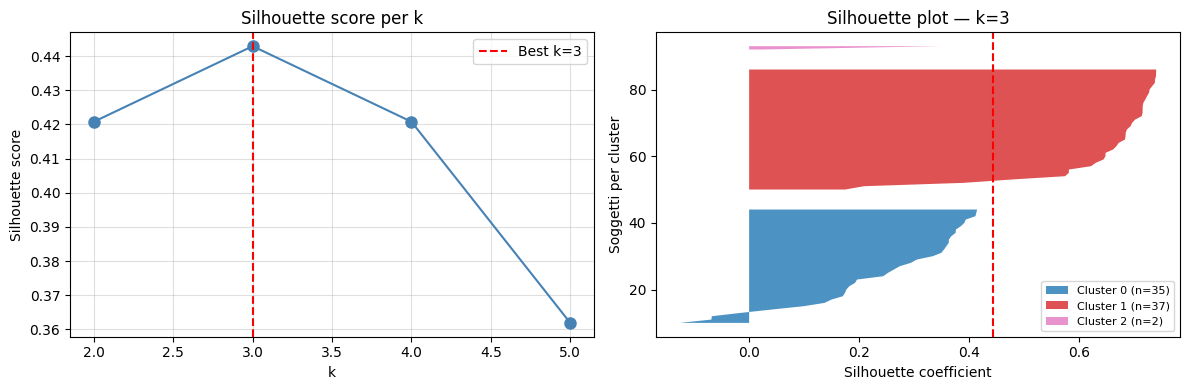

In [9]:
# ============================================================
# CLUSTERING K-MEANS: k = 2, 3, 4, 5
# ============================================================

# Input clustering: X_pca (n_PCA componenti)
X_clust = X_pca

kmeans_results = {}
silhouette_scores = {}

print("K-Means clustering:")
print(f"{'k':>3}  {'Silhouette':>12}  {'Inertia':>12}")
print("-" * 32)

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_clust)
    if len(set(labels)) > 1:
        sil = silhouette_score(X_clust, labels)
    else:
        sil = 0.0
    kmeans_results[k]     = labels
    silhouette_scores[k]  = sil
    sizes = [int((labels == c).sum()) for c in range(k)]
    print(f"{k:>3}  {sil:>12.4f}  {km.inertia_:>12.1f}   cluster_sizes={sizes}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k (silhouette): {best_k}  (score={silhouette_scores[best_k]:.4f})")

# ---- Plot silhouette per k ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_RANGE, [silhouette_scores[k] for k in K_RANGE], "o-", color="steelblue", markersize=8)
axes[0].axvline(best_k, color="red", ls="--", label=f"Best k={best_k}")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Silhouette score per k"); axes[0].legend()
axes[0].grid(alpha=0.4)

# Silhouette samples per best_k
best_labels = kmeans_results[best_k]
sil_samples = silhouette_samples(X_clust, best_labels)
y_lower = 10
colors   = cm.tab10(np.arange(best_k) / best_k)
for c_id in range(best_k):
    c_sil = np.sort(sil_samples[best_labels == c_id])
    y_upper = y_lower + len(c_sil)
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                           facecolor=colors[c_id], edgecolor="none", alpha=0.8,
                           label=f"Cluster {c_id} (n={len(c_sil)})")
    y_lower = y_upper + 5
axes[1].axvline(silhouette_scores[best_k], color="red", ls="--", lw=1.5)
axes[1].set_xlabel("Silhouette coefficient"); axes[1].set_ylabel("Soggetti per cluster")
axes[1].set_title(f"Silhouette plot — k={best_k}"); axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_kmeans_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()

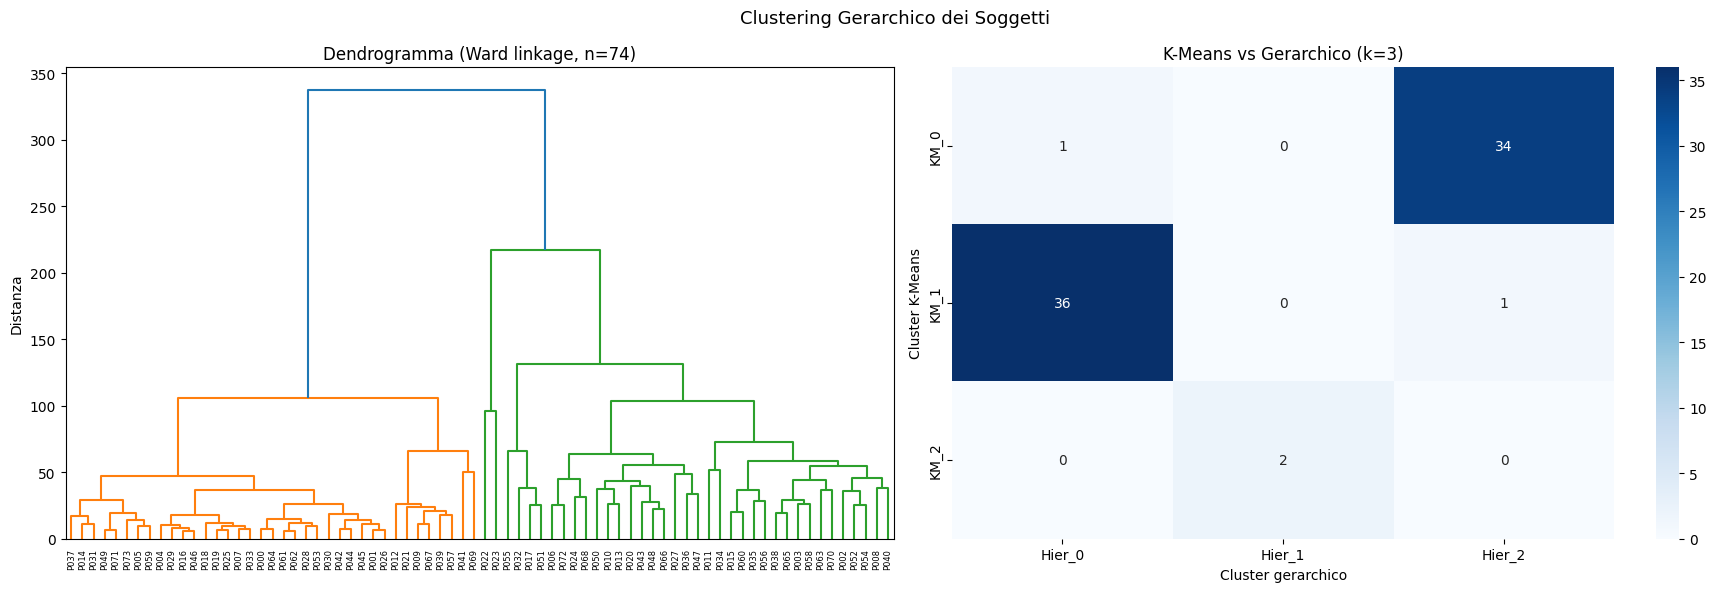

Adjusted Rand Index (K-Means vs Gerarchico, k=3): 0.896
  (1.0 = accordo perfetto, 0.0 = casuale)


In [10]:
# ============================================================
# CLUSTERING GERARCHICO + DENDROGRAMMA
# ============================================================

# Linkage su X_pca (Ward)
Z = linkage(X_clust, method="ward", metric="euclidean")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Clustering Gerarchico dei Soggetti", fontsize=13)

# Dendrogramma
dend = dendrogram(
    Z, labels=subject_ids, ax=axes[0],
    leaf_rotation=90, leaf_font_size=6,
    color_threshold=0.7 * max(Z[:, 2]),
)
axes[0].set_title(f"Dendrogramma (Ward linkage, n={n_subj})")
axes[0].set_ylabel("Distanza")

# Confronto flat clustering gerarchico con K-Means al best_k
hier_labels = fcluster(Z, t=best_k, criterion="maxclust") - 1  # 0-indexed
km_labels   = kmeans_results[best_k]

# Heatmap accordo K-Means vs gerarchico
from sklearn.metrics import confusion_matrix
conf = confusion_matrix(km_labels, hier_labels)
sns.heatmap(conf, annot=True, fmt="d", ax=axes[1], cmap="Blues",
            xticklabels=[f"Hier_{c}" for c in range(best_k)],
            yticklabels=[f"KM_{c}"   for c in range(best_k)])
axes[1].set_title(f"K-Means vs Gerarchico (k={best_k})")
axes[1].set_xlabel("Cluster gerarchico")
axes[1].set_ylabel("Cluster K-Means")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_hierarchical_clustering.png", dpi=120, bbox_inches="tight")
plt.show()

# Accordo (Adjusted Rand Index)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(km_labels, hier_labels)
print(f"Adjusted Rand Index (K-Means vs Gerarchico, k={best_k}): {ari:.3f}")
print("  (1.0 = accordo perfetto, 0.0 = casuale)")

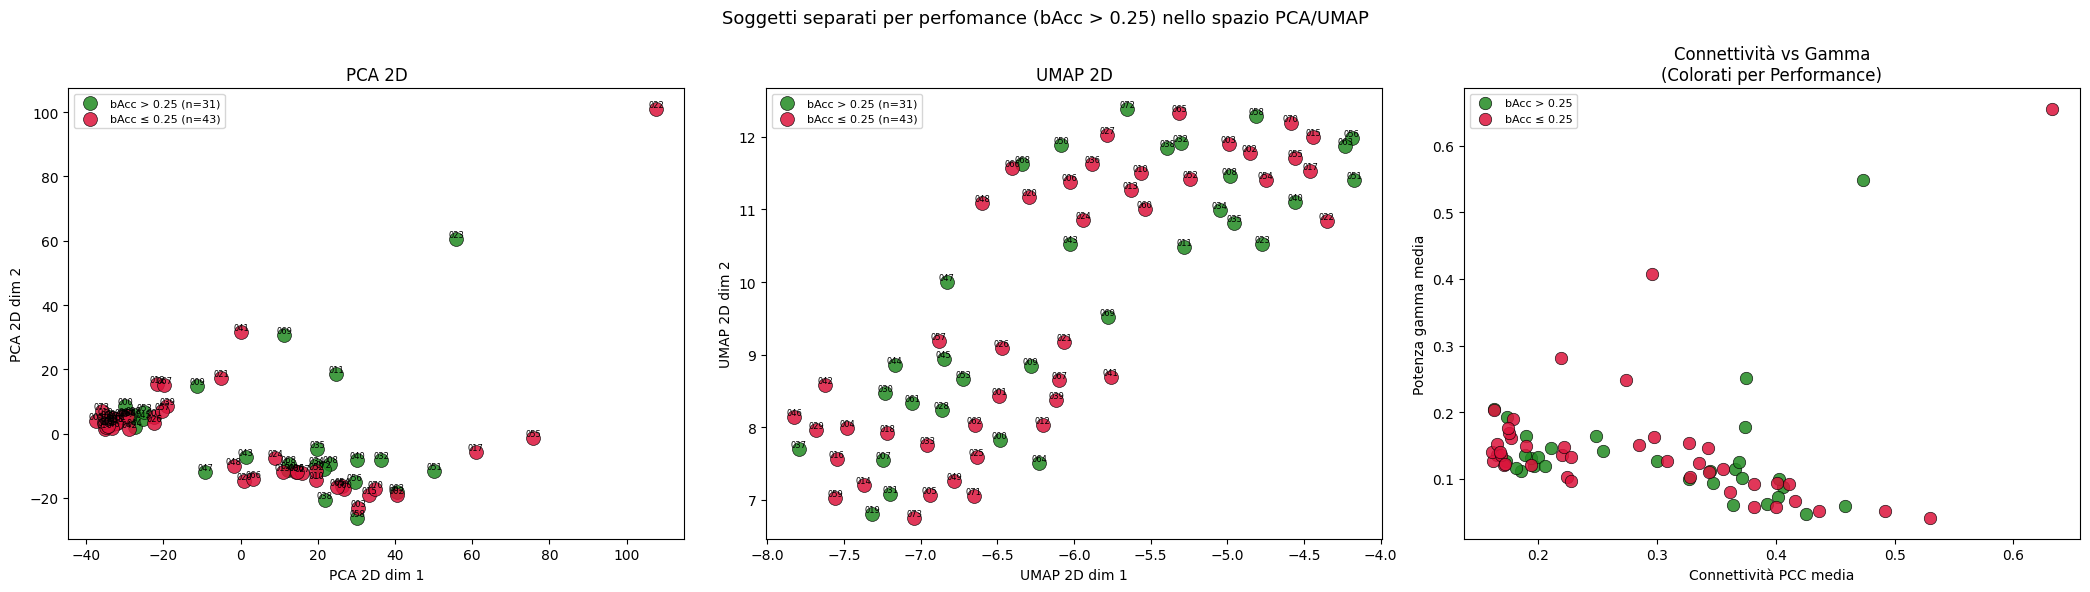


Riepilogo soggetti (Baseline bAcc = 0.25):
Sopra (31 soggetti): PCC.μ = 0.2988, Gamma.μ = 0.1366
Sotto (43 soggetti): PCC.μ = 0.2851, Gamma.μ = 0.1468


In [11]:
# ============================================================
# VISUALIZZAZIONE CLUSTER NELLO SPAZIO 2D (PCA + UMAP)
# (Colorati per performance rispetto a baseline bAcc)
# ============================================================

# Manteniamo la definizione dei cluster per le celle successive del notebook
FINAL_CLUSTER_LABELS = kmeans_results[best_k]   
CLUSTER_COLORS = plt.cm.tab10(np.arange(best_k) / best_k)

# --- NUOVO: Caricamento bAcc per colorare lo spazio ---
baseline = 0.25
subj_is_above = np.zeros(len(subject_ids), dtype=bool)

# Utilizziamo il path del file aggiornato che ha generato il ranking
results_csv_pth = INTERIM_DIR / "eeg06_ss_4_results.csv"
if not results_csv_pth.exists():
    results_csv_pth = project_root / "data" / "interim" / "eeg06_results.csv"

if results_csv_pth.exists():
    _df_res = pd.read_csv(results_csv_pth)
    _acc_col = "test_bacc" if "test_bacc" in _df_res.columns else "test_acc"
    if "subject" in _df_res.columns:
        # Prendi la media della bAcc per soggetto dai risultati del CSV
        _subj_acc = _df_res.groupby("subject")[_acc_col].mean().to_dict()
        for i, sid in enumerate(subject_ids):
            # Normalizza stringa se `subject_ids` è tipo P066 -> interecettato come int 66
            sid_int = int(str(sid).replace("P", ""))
            acc = _subj_acc.get(sid_int, _subj_acc.get(sid, 0.0))
            subj_is_above[i] = (acc > baseline)
else:
    print(f"⚠️ Impossibile trovare {results_csv_pth}")

# Aggiungi colore in base alle performance come dimensione extra
fig_cols = 2 + (1 if X_umap is not None else 0)
fig, axes = plt.subplots(1, fig_cols, figsize=(7 * fig_cols, 6))
fig.suptitle(f"Soggetti separati per perfomance (bAcc > {baseline}) nello spazio PCA/UMAP", fontsize=13)

projs = [(X_pca2d, "PCA 2D")]
if X_umap is not None:
    projs.append((X_umap, "UMAP 2D"))

mask_above = subj_is_above
mask_below = ~subj_is_above

for ax_idx, (proj, title) in enumerate(projs):
    ax = axes[ax_idx]
    
    # Plot soggetti SPLIT > Baseline (Verde)
    ax.scatter(proj[mask_above, 0], proj[mask_above, 1],
               s=100, label=f"bAcc > {baseline} (n={mask_above.sum()})",
               color="forestgreen", edgecolors="black", linewidths=0.5, alpha=0.85)
    # Plot soggetti SPLIT <= Baseline (Rosso)
    ax.scatter(proj[mask_below, 0], proj[mask_below, 1],
               s=100, label=f"bAcc ≤ {baseline} (n={mask_below.sum()})",
               color="crimson", edgecolors="black", linewidths=0.5, alpha=0.85)

    for i, sid in enumerate(subject_ids):
        ax.annotate(sid.replace("P", ""), (proj[i, 0], proj[i, 1]),
                    fontsize=6, ha="center", va="bottom")
    ax.set_xlabel(f"{title} dim 1"); ax.set_ylabel(f"{title} dim 2")
    ax.set_title(f"{title}")
    ax.legend(fontsize=8)

# Plot: feature discriminanti per la performance piuttosto che per il cluster
ax_feat = axes[-1]
gamma_idx = list(FREQ_BANDS.keys()).index("gamma")
bp_gamma_per_subj = band_power_mat[:, :, gamma_idx].mean(axis=1)  # (N_subj,)

ax_feat.scatter(mean_connectivity[mask_above], bp_gamma_per_subj[mask_above],
                s=80, label=f"bAcc > {baseline}",
                color="forestgreen", edgecolors="black", lw=0.5, alpha=0.85)
ax_feat.scatter(mean_connectivity[mask_below], bp_gamma_per_subj[mask_below],
                s=80, label=f"bAcc ≤ {baseline}",
                color="crimson", edgecolors="black", lw=0.5, alpha=0.85)

ax_feat.set_xlabel("Connettività PCC media")
ax_feat.set_ylabel("Potenza gamma media")
ax_feat.set_title("Connettività vs Gamma\n(Colorati per Performance)")
ax_feat.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_cluster_visualization_baseline.png", dpi=120, bbox_inches="tight")
plt.show()

# Riepilogo gruppi: quanti soggetti sono rimasti sopra/sotto
print(f"\nRiepilogo soggetti (Baseline bAcc = {baseline}):")
print(f"Sopra ({mask_above.sum()} soggetti): PCC.μ = {mean_connectivity[mask_above].mean():.4f}, Gamma.μ = {bp_gamma_per_subj[mask_above].mean():.4f}")
print(f"Sotto ({mask_below.sum()} soggetti): PCC.μ = {mean_connectivity[mask_below].mean():.4f}, Gamma.μ = {bp_gamma_per_subj[mask_below].mean():.4f}")


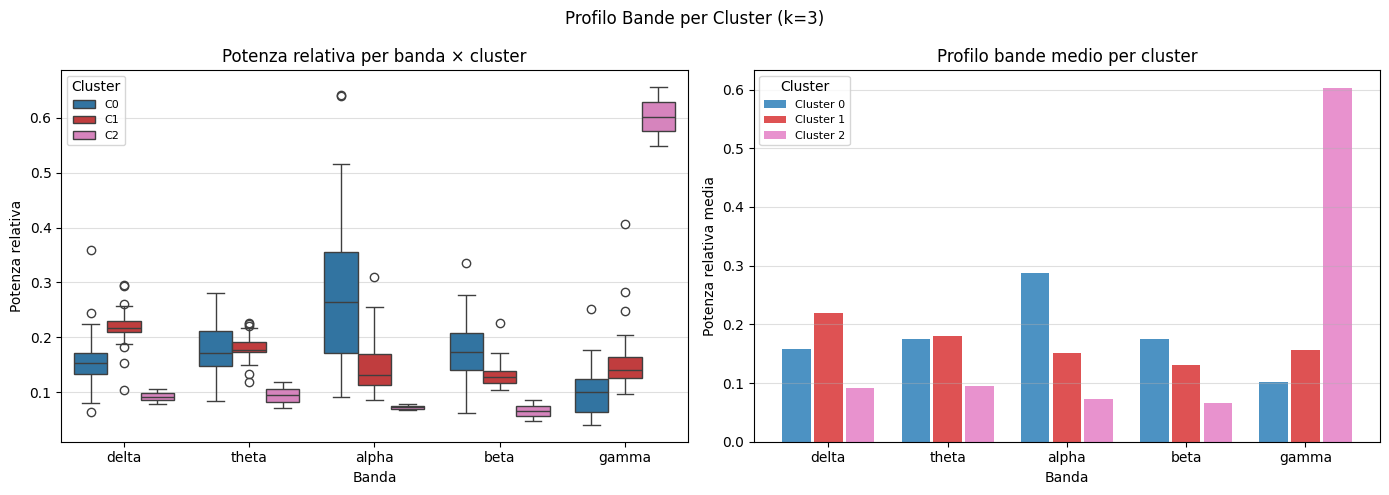


ANOVA tra cluster per banda (potenza media per soggetto):
   Banda         F           p    Sig
   delta    21.058      0.0000    ***
   theta     5.075      0.0087     **
   alpha    17.007      0.0000    ***
    beta    12.067      0.0000    ***
   gamma    91.757      0.0000    ***


In [12]:
# ============================================================
# PROFILO BANDE PER CLUSTER
# Ispirato da Iacomi 2026: analisi per banda separata
# ============================================================

band_names = list(FREQ_BANDS.keys())
n_bands    = len(band_names)

# Potenza media per banda, per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Profilo Bande per Cluster (k={best_k})", fontsize=12)

# Grouped boxplot per banda e cluster
data_box = []
for b_idx, b_name in enumerate(band_names):
    for c_id in range(best_k):
        mask = FINAL_CLUSTER_LABELS == c_id
        for val in band_power_mat[mask, :, b_idx].mean(axis=1):
            data_box.append({"Banda": b_name, "Cluster": f"C{c_id}", "Potenza": val})
df_box = pd.DataFrame(data_box)

cluster_palette = {f"C{c_id}": CLUSTER_COLORS[c_id] for c_id in range(best_k)}
sns.boxplot(data=df_box, x="Banda", y="Potenza", hue="Cluster",
            palette=cluster_palette, ax=axes[0])
axes[0].set_title("Potenza relativa per banda × cluster")
axes[0].set_xlabel("Banda"); axes[0].set_ylabel("Potenza relativa")
axes[0].legend(title="Cluster", fontsize=8)
axes[0].grid(axis="y", alpha=0.4)

# Radar chart: profilo medio per cluster
from matplotlib.patches import FancyArrowPatch
angles   = np.linspace(0, 2 * np.pi, n_bands, endpoint=False)
angles   = np.concatenate([angles, [angles[0]]])  # chiudi il cerchio

ax_radar = plt.subplot(122, projection="polar") if False else axes[1]
# Fallback: se non polar, usa lineare
cluster_bp_profiles = []
for c_id in range(best_k):
    mask = FINAL_CLUSTER_LABELS == c_id
    profile = band_power_mat[mask, :, :].mean(axis=(0, 1))  # (N_BANDS,)
    cluster_bp_profiles.append(profile)

x_pos = np.arange(n_bands)
width = 0.8 / best_k
for c_id, profile in enumerate(cluster_bp_profiles):
    axes[1].bar(x_pos + c_id * width, profile, width=width * 0.9,
                label=f"Cluster {c_id}", color=CLUSTER_COLORS[c_id], alpha=0.8)
axes[1].set_xticks(x_pos + width * (best_k - 1) / 2)
axes[1].set_xticklabels(band_names)
axes[1].set_xlabel("Banda"); axes[1].set_ylabel("Potenza relativa media")
axes[1].set_title("Profilo bande medio per cluster")
axes[1].legend(title="Cluster", fontsize=8)
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_band_profile_per_cluster.png", dpi=120, bbox_inches="tight")
plt.show()

# ANOVA per banda tra cluster
print("\nANOVA tra cluster per banda (potenza media per soggetto):")
print(f"{'Banda':>8}  {'F':>8}  {'p':>10}  {'Sig':>5}")
for b_idx, b_name in enumerate(band_names):
    groups = [band_power_mat[FINAL_CLUSTER_LABELS == c_id, :, b_idx].mean(axis=1)
              for c_id in range(best_k)]
    F, p = f_oneway(*groups)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    print(f"{b_name:>8}  {F:>8.3f}  {p:>10.4f}  {sig:>5}")

In [13]:
# ============================================================
# OVERLAP CON PERFORMANCE EEG_06
# Carica RESULTS_CSV e unisce con cluster label
# ============================================================

results_path = Path(EEG06_RESULTS_CSV)
if not results_path.is_absolute():
    results_path = project_root / results_path

if not results_path.exists():
    for alt in [
        project_root / "data" / "interim" / "eeg_06_ss_norm_results.csv",
        project_root / "data" / "interim" / "eeg06_results.csv",
        project_root / "data" / "interim" / "results_subject_specific.csv",
    ]:
        if alt.exists():
            results_path = alt
            print(f"Trovato in: {alt.name}")
            break

if not results_path.exists():
    print(f"⚠️  File risultati EEG_06 non trovato.")
    print(f"   Cercato: {results_path}")
    print("   Esegui prima EEG_06_subject_specific.ipynb.")
    HAS_EEG06 = False
else:
    df_results = pd.read_csv(results_path)
    print(f"Caricati: {results_path.name}  ({len(df_results)} righe)")
    print(f"Colonne : {list(df_results.columns)}")
    print(df_results.head())
    HAS_EEG06 = True

Righe con cluster assegnato: 615

Accuracy media per cluster:
           mean     std  count
cluster                       
0        0.3600  0.0475    282
1        0.3652  0.0524    321
2        0.3689  0.0543     12


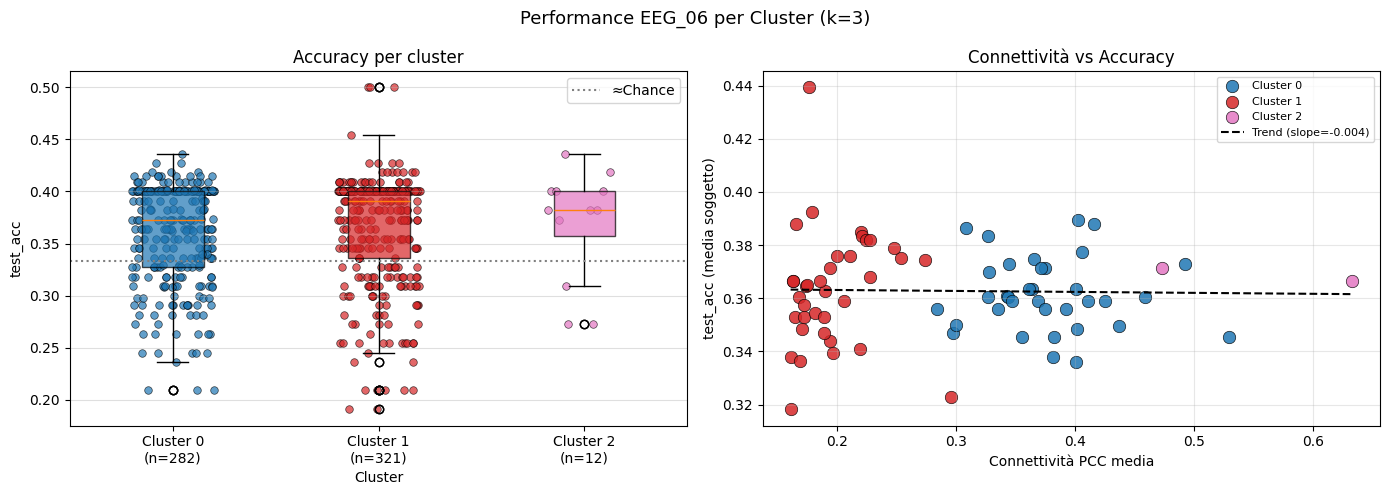


ANOVA accuracy tra cluster: F=0.892, p=0.4102
Kruskal-Wallis           : p=0.2920
⚪ Differenza NON significativa — cluster simili in performance


In [14]:
# ============================================================
# BOXPLOT ACCURACY PER CLUSTER + ANOVA
# ============================================================

if not HAS_EEG06:
    print("Salto: nessun file EEG_06 trovato.")
else:
    # ---- Costruisci mapping soggetto → cluster ----
    subj2cluster = {s: int(FINAL_CLUSTER_LABELS[i]) for i, s in enumerate(subject_ids)}

    # Normalizza ID soggetto nel CSV risultati
    # Il CSV potrebbe avere "P003", "003", "3", ecc.
    def normalize_subj_id(sid):
        """Porta a formato 'PXXX' (3 cifre)"""
        sid_str = str(sid).lstrip("P").zfill(3)
        return f"P{sid_str}"

    df_results["subj_norm"] = df_results["subject"].apply(
        lambda x: normalize_subj_id(x) if "subject" in df_results.columns else None
    )

    # Cerca colonna soggetto
    subj_col = None
    for col in ["subject", "subj", "subject_id", "Subject"]:
        if col in df_results.columns:
            subj_col = col
            break
    acc_col = None
    for col in ["test_acc", "accuracy", "acc", "test_accuracy"]:
        if col in df_results.columns:
            acc_col = col
            break

    if subj_col is None or acc_col is None:
        print(f"❌ Colonne non trovate. Colonne disponibili: {list(df_results.columns)}")
        print(f"   Imposta subj_col e acc_col manualmente.")
        HAS_EEG06 = False
    else:
        df_results["subj_norm"] = df_results[subj_col].apply(normalize_subj_id)
        df_results["cluster"]   = df_results["subj_norm"].map(subj2cluster)

        n_missing = df_results["cluster"].isna().sum()
        if n_missing > 0:
            print(f"⚠️  {n_missing} righe senza cluster (soggetto non in subject_ids) — rimosse.")
        df_merge = df_results.dropna(subset=["cluster"]).copy()
        df_merge["cluster"] = df_merge["cluster"].astype(int)

        print(f"Righe con cluster assegnato: {len(df_merge)}")
        print(f"\nAccuracy media per cluster:")
        print(df_merge.groupby("cluster")[acc_col].agg(["mean", "std", "count"]).round(4))

        # ---- Plot boxplot accuracy per cluster ----
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Performance EEG_06 per Cluster (k={best_k})", fontsize=13)

        # Boxplot
        cluster_data = [df_merge[df_merge["cluster"] == c][acc_col].values
                        for c in range(best_k)]
        bp = axes[0].boxplot(cluster_data, patch_artist=True,
                              labels=[f"Cluster {c}\n(n={len(d)})" for c, d in enumerate(cluster_data)])
        for patch, color in zip(bp["boxes"], CLUSTER_COLORS):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        # Sovrapponi i punti
        for c_id, data_c in enumerate(cluster_data):
            x_jitter = np.random.default_rng(c_id).uniform(-0.2, 0.2, len(data_c))
            axes[0].scatter((c_id + 1) + x_jitter, data_c,
                             color=CLUSTER_COLORS[c_id], edgecolors="black",
                             linewidths=0.5, alpha=0.7, s=30)
        axes[0].axhline(1 / len(df_merge["cluster"].unique()),  # chance level circa
                         color="gray", ls=":", label="≈Chance")
        axes[0].set_xlabel("Cluster"); axes[0].set_ylabel(f"{acc_col}")
        axes[0].set_title("Accuracy per cluster"); axes[0].legend()
        axes[0].grid(axis="y", alpha=0.4)

        # Scatter: connettività PCC media vs accuracy
        subj_acc_mean = df_merge.groupby("subj_norm")[acc_col].mean().to_dict()
        x_conn, y_acc, c_labels = [], [], []
        for i, s in enumerate(subject_ids):
            if s in subj_acc_mean:
                x_conn.append(mean_connectivity[i])
                y_acc.append(subj_acc_mean[s])
                c_labels.append(FINAL_CLUSTER_LABELS[i])
        x_conn, y_acc, c_labels = map(np.array, [x_conn, y_acc, c_labels])

        for c_id in range(best_k):
            m = c_labels == c_id
            axes[1].scatter(x_conn[m], y_acc[m], s=80, label=f"Cluster {c_id}",
                             color=CLUSTER_COLORS[c_id], edgecolors="black", lw=0.5, alpha=0.85)
        # Linea di tendenza
        if len(x_conn) > 2:
            z = np.polyfit(x_conn, y_acc, 1)
            p_line = np.poly1d(z)
            xs = np.linspace(x_conn.min(), x_conn.max(), 50)
            axes[1].plot(xs, p_line(xs), "k--", lw=1.5, label=f"Trend (slope={z[0]:.3f})")
        axes[1].set_xlabel("Connettività PCC media")
        axes[1].set_ylabel(f"{acc_col} (media soggetto)")
        axes[1].set_title("Connettività vs Accuracy")
        axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

        plt.tight_layout()
        fig.savefig(FIGURES_DIR / "eeg08_accuracy_per_cluster.png", dpi=120, bbox_inches="tight")
        plt.show()

        # ANOVA
        if len(cluster_data) > 1 and all(len(d) > 0 for d in cluster_data):
            F, p_anova = f_oneway(*cluster_data)
            _, p_kw    = kruskal(*cluster_data)
            print(f"\nANOVA accuracy tra cluster: F={F:.3f}, p={p_anova:.4f}")
            print(f"Kruskal-Wallis           : p={p_kw:.4f}")
            if p_anova < 0.05:
                print("✅ Differenza significativa tra cluster (p<0.05)")
            else:
                print("⚪ Differenza NON significativa — cluster simili in performance")

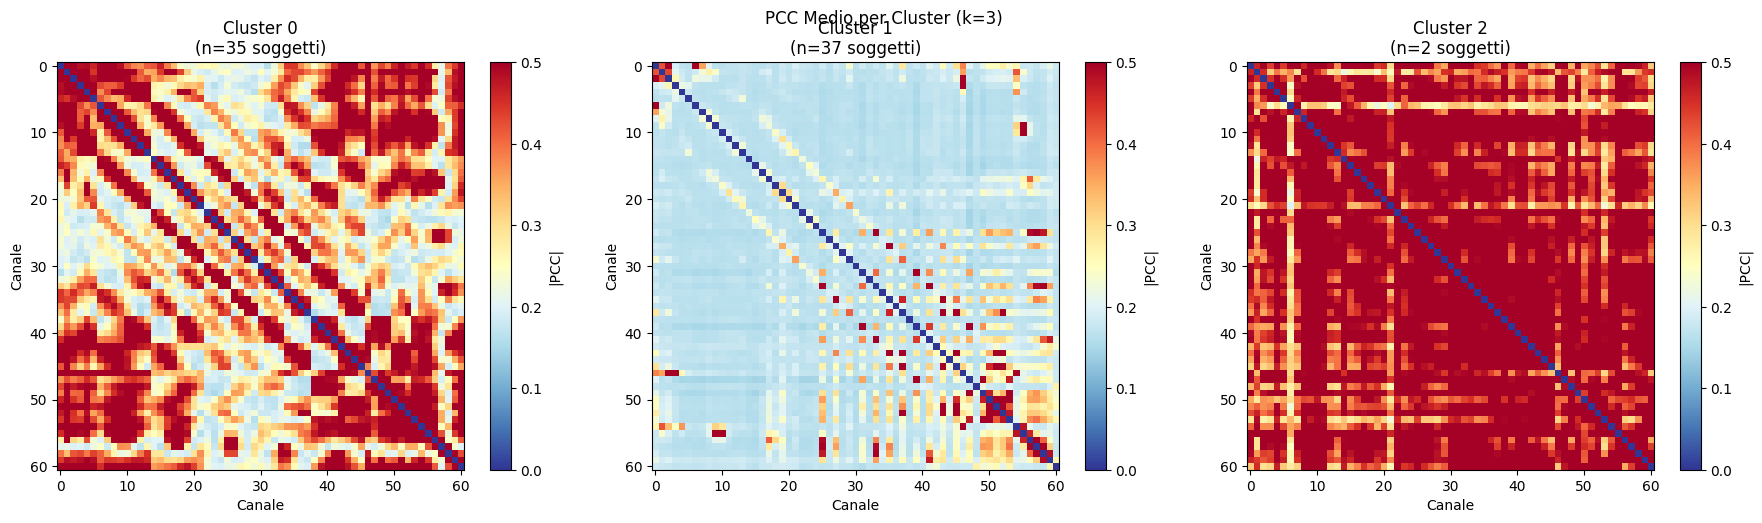

In [15]:
# ============================================================
# HEATMAP PCC MEDIA PER CLUSTER
# Caratterizzazione neurofisiologica di ogni cluster
# ============================================================

fig, axes = plt.subplots(1, best_k, figsize=(6 * best_k, 5))
if best_k == 1:
    axes = [axes]
fig.suptitle(f"PCC Medio per Cluster (k={best_k})", fontsize=12)

pcc_vmax = float(np.percentile(pcc_mean_mat[np.triu_indices(n_subj, k=1)[0],
                                             np.triu_indices(n_subj, k=1)[1]], 95)) \
           if False else 0.5

for c_id in range(best_k):
    mask = FINAL_CLUSTER_LABELS == c_id
    pcc_c = pcc_mean_mat[mask].mean(axis=0)   # (N_CHANS, N_CHANS)
    im = axes[c_id].imshow(pcc_c, cmap="RdYlBu_r", vmin=0, vmax=0.5)
    axes[c_id].set_title(f"Cluster {c_id}\n(n={mask.sum()} soggetti)")
    axes[c_id].set_xlabel("Canale"); axes[c_id].set_ylabel("Canale")
    plt.colorbar(im, ax=axes[c_id], label="|PCC|")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eeg08_pcc_per_cluster.png", dpi=120, bbox_inches="tight")
plt.show()

In [16]:
# ============================================================
# SOMMARIO E EXPORT
# ============================================================

print("=" * 65)
print(f"SOMMARIO CLUSTERING SOGGETTI (EEG_08)")
print("=" * 65)
print(f"Soggetti analizzati    : {n_subj}")
print(f"Feature per soggetto   : {X_subjects.shape[1]} "
      f"({N_CHANS}×{n_bands} band power + {n_triu} PCC + {n_graph} graph)")
print(f"Migliore k (silhouette): {best_k} (score={silhouette_scores[best_k]:.4f})")
print("")
print("Cluster:")
for c_id in range(best_k):
    mask   = FINAL_CLUSTER_LABELS == c_id
    n_c    = mask.sum()
    conn_c = mean_connectivity[mask].mean()
    gam_c  = bp_gamma_per_subj[mask].mean() if 'bp_gamma_per_subj' in dir() else float('nan')
    members = [subject_ids[i] for i in range(n_subj) if FINAL_CLUSTER_LABELS[i] == c_id]
    print(f"  Cluster {c_id}: n={n_c:2d}  conn_pcc={conn_c:.4f}  gamma={gam_c:.4f}")
    print(f"    Soggetti: {', '.join(members)}")

print("")
print("Artefatti salvati:")
for f in sorted(FIGURES_DIR.glob("eeg08_*.png")):
    print(f"  {f.name}")

# ---- Export CSV: soggetto → cluster → feature principali ----
df_export = pd.DataFrame({
    "subject":          subject_ids,
    "cluster":          FINAL_CLUSTER_LABELS,
    "mean_pcc_conn":    mean_connectivity,
    "std_pcc_conn":     std_connectivity,
    "n_trials":         [n_trials_per.get(s, 0) for s in subject_ids],
})
# Aggiungi potenza per banda
for b_idx, b_name in enumerate(band_names):
    df_export[f"bp_{b_name}"] = band_power_mat[:, :, b_idx].mean(axis=1)

export_path = INTERIM_DIR / "subject_clusters.csv"
df_export.to_csv(export_path, index=False)
print(f"\nTabella cluster esportata: {export_path}")
print(df_export.to_string(index=False))

SOMMARIO CLUSTERING SOGGETTI (EEG_08)
Soggetti analizzati    : 74
Feature per soggetto   : 2139 (61×5 band power + 1830 PCC + 4 graph)
Migliore k (silhouette): 3 (score=0.4429)

Cluster:
  Cluster 0: n=35  conn_pcc=0.3759  gamma=0.1015
    Soggetti: P002, P003, P006, P008, P010, P011, P013, P015, P017, P020, P024, P027, P032, P034, P035, P036, P038, P040, P043, P048, P050, P051, P052, P054, P055, P056, P058, P060, P063, P065, P066, P068, P069, P070, P072
  Cluster 1: n=37  conn_pcc=0.1962  gamma=0.1565
    Soggetti: P000, P001, P004, P005, P007, P009, P012, P014, P016, P018, P019, P021, P025, P026, P028, P029, P030, P031, P033, P037, P039, P041, P042, P044, P045, P046, P047, P049, P053, P057, P059, P061, P062, P064, P067, P071, P073
  Cluster 2: n= 2  conn_pcc=0.5529  gamma=0.6026
    Soggetti: P022, P023

Artefatti salvati:
  eeg08_ablation_graph_methods.png
  eeg08_acc_vs_bacc.png
  eeg08_accuracy_per_cluster.png
  eeg08_band_power_overview.png
  eeg08_band_profile_per_cluster.png
  

# ============================================================
# CLUSTERING PER FEATURE SET (APPROCCIO COMPARATIVO)
# ============================================================
Confrontiamo le diverse estrazioni di feature per capire quali offrono la miglior separazione naturale tra i soggetti, usando come metrica la **Silhouette Score**.
I set di feature sono:
- All Features (tutto concatenato, 2139 dim)
- Band Power (prime 305 dim)
- PCC (successive 1830 dim)
- Graph Metrics (ultime 4 dim)

In [17]:
# Definizione dei sottomenù di feature
feature_sets = {
    "All Features": X_subjects,
    "Band Power": X_subjects[:, :305],
    "PCC": X_subjects[:, 305:2135],
    "Graph Metrics": X_subjects[:, 2135:2139]
}

# Strutture dati per salvare i risultati
results_dict = {}
best_feature_set = None
best_silhouette = -1
best_k_global = 2
best_labels_global = None
best_X_pca = None
best_X_scaled = None

print("=== VALUTAZIONE CLUSTERING PER SET DI FEATURE ===")

for set_name, X_subset in feature_sets.items():
    try:
        print(f"\nAnalisi {set_name} (Shape: {X_subset.shape})")
        
        # 1. Standard Scaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_subset)
        
        # 2. PCA
        pca = PCA(n_components=min(N_PCA_COMPONENTS, X_scaled.shape[1]), random_state=RANDOM_STATE)
        X_pca = pca.fit_transform(X_scaled)
        var_explained = np.sum(pca.explained_variance_ratio_) * 100
        print(f"  Varianza spiegata da {X_pca.shape[1]} componenti PCA: {var_explained:.1f}%")
        
        # 3. K-Means Clustering su PCA
        best_k_local = 2
        best_sil_local = -1
        best_labels_local = None
        
        for k in K_RANGE:
            kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            labels = kmeans.fit_predict(X_pca)
            
            sil_score = silhouette_score(X_pca, labels, random_state=RANDOM_STATE)
            
            if sil_score > best_sil_local:
                best_sil_local = sil_score
                best_k_local = k
                best_labels_local = labels
                
        print(f"  Miglior K = {best_k_local} (Silhouette: {best_sil_local:.4f})")
        
        results_dict[set_name] = {
            "best_k": best_k_local,
            "silhouette": best_sil_local,
            "var_explained": var_explained
        }
        
        if best_sil_local > best_silhouette:
            best_silhouette = best_sil_local
            best_feature_set = set_name
            best_k_global = best_k_local
            best_labels_global = best_labels_local
            best_X_pca = X_pca
            best_X_scaled = X_scaled
    except Exception as e:
        print(f"  Errore in {set_name}: {e}")

print("\n" + "="*50)
print(f"IL SET DI FEATURE MIGLIORE E': {best_feature_set} con Silhouette Score {best_silhouette:.4f} (k={best_k_global})")
print("="*50)
# Manteniamo questa compatibilità esplicita così la cella dopo non si arrabbia!
kmeans_results = {best_k_global: best_labels_global}
best_k = best_k_global

=== VALUTAZIONE CLUSTERING PER SET DI FEATURE ===

Analisi All Features (Shape: (74, 2139))
  Varianza spiegata da 20 componenti PCA: 88.9%
  Miglior K = 3 (Silhouette: 0.4429)

Analisi Band Power (Shape: (74, 305))
  Varianza spiegata da 20 componenti PCA: 92.6%
  Miglior K = 3 (Silhouette: 0.3451)

Analisi PCC (Shape: (74, 1830))
  Varianza spiegata da 20 componenti PCA: 89.8%
  Miglior K = 3 (Silhouette: 0.4690)

Analisi Graph Metrics (Shape: (74, 4))
  Varianza spiegata da 4 componenti PCA: 100.0%
  Miglior K = 3 (Silhouette: 0.4923)

IL SET DI FEATURE MIGLIORE E': Graph Metrics con Silhouette Score 0.4923 (k=3)


# ============================================================
# VISUALIZZAZIONE SPAZIO E PERFORMANCE PER IL BEST FEATURE SET
# ============================================================


Visualizzazione spazio UMAP/PCA calcolata su: Graph Metrics
Colonne attese mancanti nel CSV o nome colonne da verificare. Procedo colorando solo per Cluster.


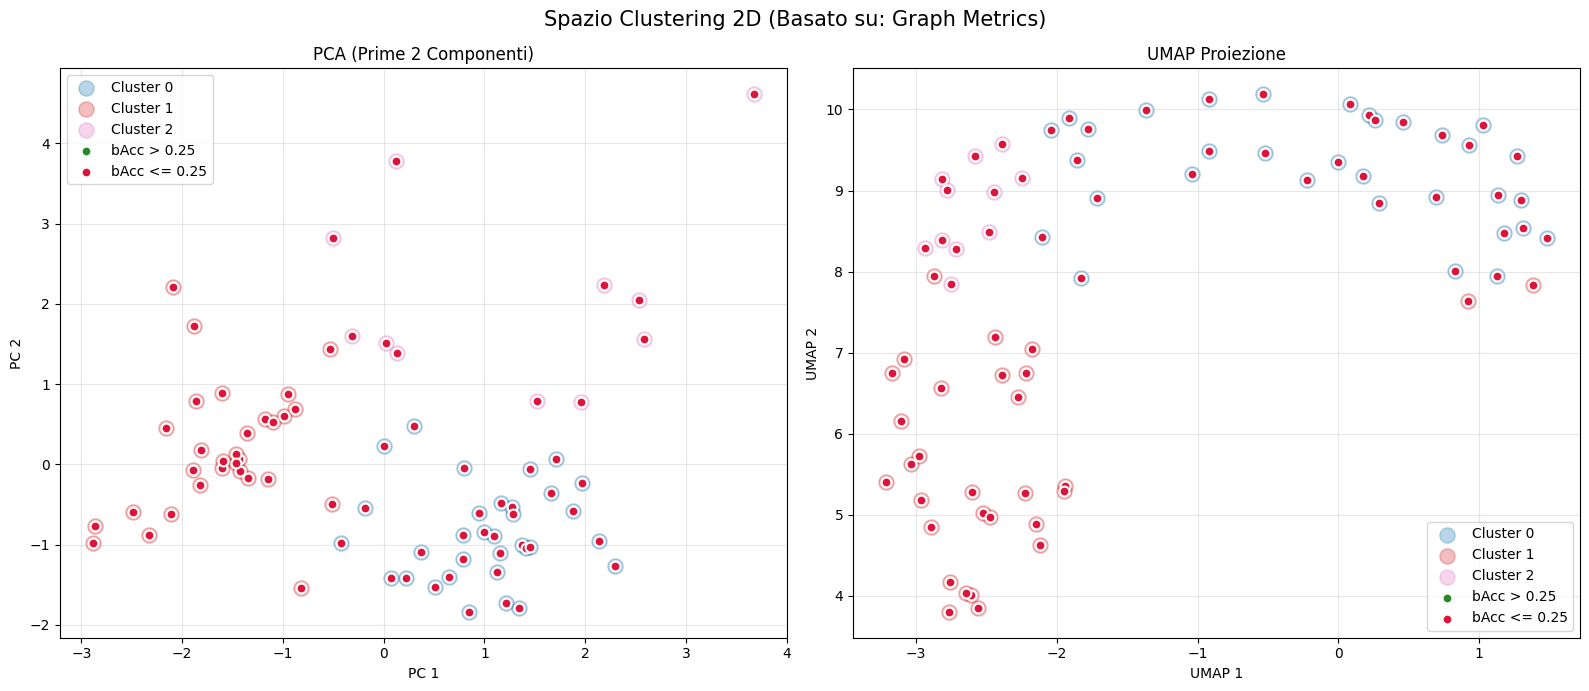

In [18]:
print(f"Visualizzazione spazio UMAP/PCA calcolata su: {best_feature_set}")

FINAL_CLUSTER_LABELS = kmeans_results[best_k_global]   
CLUSTER_COLORS = plt.cm.tab10(np.arange(best_k_global) / best_k_global)

# --- NUOVO: Caricamento bAcc per colorare lo spazio ---
PERF_CSV_PATH = "../data/interim/eeg06_ss_4_results.csv"  # Assicurati sia il path giusto
bacc_array = []
is_high_perf = []

try:
    df_perf = pd.read_csv(PERF_CSV_PATH)
    # Supponiamo che il df contenga colonne 'Soggetto' e 'Balanced_Accuracy'
    # Facciamo la media su tutti i modelli per ogni soggetto (come avevamo fatto in passato)
    if 'Soggetto' in df_perf.columns and 'Balanced_Accuracy' in df_perf.columns:
        df_subj_perf = df_perf.groupby('Soggetto')['Balanced_Accuracy'].mean().reset_index()
        perf_dict = dict(zip(df_subj_perf['Soggetto'].astype(str), df_subj_perf['Balanced_Accuracy']))
        
        baseline = 0.25 # Livello random Chance=25%
        
        for subj in subject_ids:
            subj_str = str(subj)
            if subj_str in perf_dict:
                bacc = perf_dict[subj_str]
                bacc_array.append(bacc)
                is_high_perf.append(bacc > baseline)
            else:
                bacc_array.append(np.nan)
                is_high_perf.append(False)
        
        is_high_perf = np.array(is_high_perf)
    else:
        print("Colonne attese mancanti nel CSV o nome colonne da verificare. Procedo colorando solo per Cluster.")
        is_high_perf = np.zeros(len(subject_ids), dtype=bool)
except Exception as e:
    print(f"Errore caricamento performance: {e}. Procedo colorando solo per cluster.")
    is_high_perf = np.zeros(len(subject_ids), dtype=bool)

# --- CALCOLO UMAP ---
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(best_X_scaled)
else:
    X_umap = best_X_pca[:, :2] # Fallback se umap non è installato


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"Spazio Clustering 2D (Basato su: {best_feature_set})", fontsize=15)

ax = axes[0]
for k in range(best_k_global):
    mask_c = (FINAL_CLUSTER_LABELS == k)
    ax.scatter(
        best_X_pca[mask_c, 0], best_X_pca[mask_c, 1], 
        s=120, alpha=0.3, color=CLUSTER_COLORS[k], 
        label=f"Cluster {k}"
    )

ax.scatter(best_X_pca[is_high_perf, 0], best_X_pca[is_high_perf, 1], 
           s=50, c="forestgreen", edgecolor="white", lw=1.5, zorder=5, label="bAcc > 0.25")
ax.scatter(best_X_pca[~is_high_perf, 0], best_X_pca[~is_high_perf, 1], 
           s=50, c="crimson", edgecolor="white", lw=1.5, zorder=5, label="bAcc <= 0.25")
ax.set_title("PCA (Prime 2 Componenti)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
if HAS_UMAP:
    for k in range(best_k_global):
        mask_c = (FINAL_CLUSTER_LABELS == k)
        ax.scatter(
            X_umap[mask_c, 0], X_umap[mask_c, 1], 
            s=120, alpha=0.3, color=CLUSTER_COLORS[k], 
            label=f"Cluster {k}"
        )
    ax.scatter(X_umap[is_high_perf, 0], X_umap[is_high_perf, 1], 
               s=50, c="forestgreen", edgecolor="white", lw=1.5, zorder=5, label="bAcc > 0.25")
    ax.scatter(X_umap[~is_high_perf, 0], X_umap[~is_high_perf, 1], 
               s=50, c="crimson", edgecolor="white", lw=1.5, zorder=5, label="bAcc <= 0.25")
    ax.set_title("UMAP Proiezione")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend()
else:
    ax.text(0.5, 0.5, "UMAP non disponibile", ha='center', va='center')

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eeg08_best_feature_clustering_scatter.png", dpi=120, bbox_inches="tight")
plt.show()


# ============================================================
# CLUSTERING PER FEATURE SET (APPROCCIO COMPARATIVO)
# ============================================================
Confrontiamo le diverse estrazioni di feature per capire quali offrono la miglior separazione naturale tra i soggetti, usando come metrica la **Silhouette Score**.
I set di feature sono:
- All Features (tutto concatenato, 2139 dim)
- Band Power (prime 305 dim)
- PCC (successive 1830 dim)
- Graph Metrics (ultime 4 dim)

In [19]:
# Definizione dei sottomenù di feature
feature_sets = {
    "All Features": X_subjects,
    "Band Power": X_subjects[:, :305],
    "PCC": X_subjects[:, 305:2135],
    "Graph Metrics": X_subjects[:, 2135:2139]
}

# Strutture dati per salvare i risultati
results_dict = {}
best_feature_set = None
best_silhouette = -1
best_k_global = 2
best_labels_global = None
best_X_pca = None
best_X_scaled = None

print("=== VALUTAZIONE CLUSTERING PER SET DI FEATURE ===")

for set_name, X_subset in feature_sets.items():
    try:
        print(f"\nAnalisi {set_name} (Shape: {X_subset.shape})")
        
        # 1. Standard Scaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_subset)
        
        # 2. PCA
        pca = PCA(n_components=min(N_PCA_COMPONENTS, X_scaled.shape[1]), random_state=RANDOM_STATE)
        X_pca = pca.fit_transform(X_scaled)
        var_explained = np.sum(pca.explained_variance_ratio_) * 100
        print(f"  Varianza spiegata da {X_pca.shape[1]} componenti PCA: {var_explained:.1f}%")
        
        # 3. K-Means Clustering su PCA
        best_k_local = 2
        best_sil_local = -1
        best_labels_local = None
        
        for k in K_RANGE:
            kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            labels = kmeans.fit_predict(X_pca)
            
            sil_score = silhouette_score(X_pca, labels, random_state=RANDOM_STATE)
            
            if sil_score > best_sil_local:
                best_sil_local = sil_score
                best_k_local = k
                best_labels_local = labels
                
        print(f"  Miglior K = {best_k_local} (Silhouette: {best_sil_local:.4f})")
        
        results_dict[set_name] = {
            "best_k": best_k_local,
            "silhouette": best_sil_local,
            "var_explained": var_explained
        }
        
        if best_sil_local > best_silhouette:
            best_silhouette = best_sil_local
            best_feature_set = set_name
            best_k_global = best_k_local
            best_labels_global = best_labels_local
            best_X_pca = X_pca
            best_X_scaled = X_scaled
    except Exception as e:
        print(f"  Errore in {set_name}: {e}")

print("\n" + "="*50)
print(f"IL SET DI FEATURE MIGLIORE E': {best_feature_set} con Silhouette Score {best_silhouette:.4f} (k={best_k_global})")
print("="*50)
# Manteniamo questa compatibilità esplicita così la cella dopo non si arrabbia!
kmeans_results = {best_k_global: best_labels_global}
best_k = best_k_global

=== VALUTAZIONE CLUSTERING PER SET DI FEATURE ===

Analisi All Features (Shape: (74, 2139))
  Varianza spiegata da 20 componenti PCA: 88.9%
  Miglior K = 3 (Silhouette: 0.4429)

Analisi Band Power (Shape: (74, 305))
  Varianza spiegata da 20 componenti PCA: 92.6%
  Miglior K = 3 (Silhouette: 0.3451)

Analisi PCC (Shape: (74, 1830))
  Varianza spiegata da 20 componenti PCA: 89.8%
  Miglior K = 3 (Silhouette: 0.4690)

Analisi Graph Metrics (Shape: (74, 4))
  Varianza spiegata da 4 componenti PCA: 100.0%
  Miglior K = 3 (Silhouette: 0.4923)

IL SET DI FEATURE MIGLIORE E': Graph Metrics con Silhouette Score 0.4923 (k=3)


# ============================================================
# VISUALIZZAZIONE SPAZIO E PERFORMANCE PER IL BEST FEATURE SET
# ============================================================


Visualizzazione spazio UMAP/PCA calcolata su: Graph Metrics
Attenzione: soggetto P073 non trovato nel CSV delle performance!


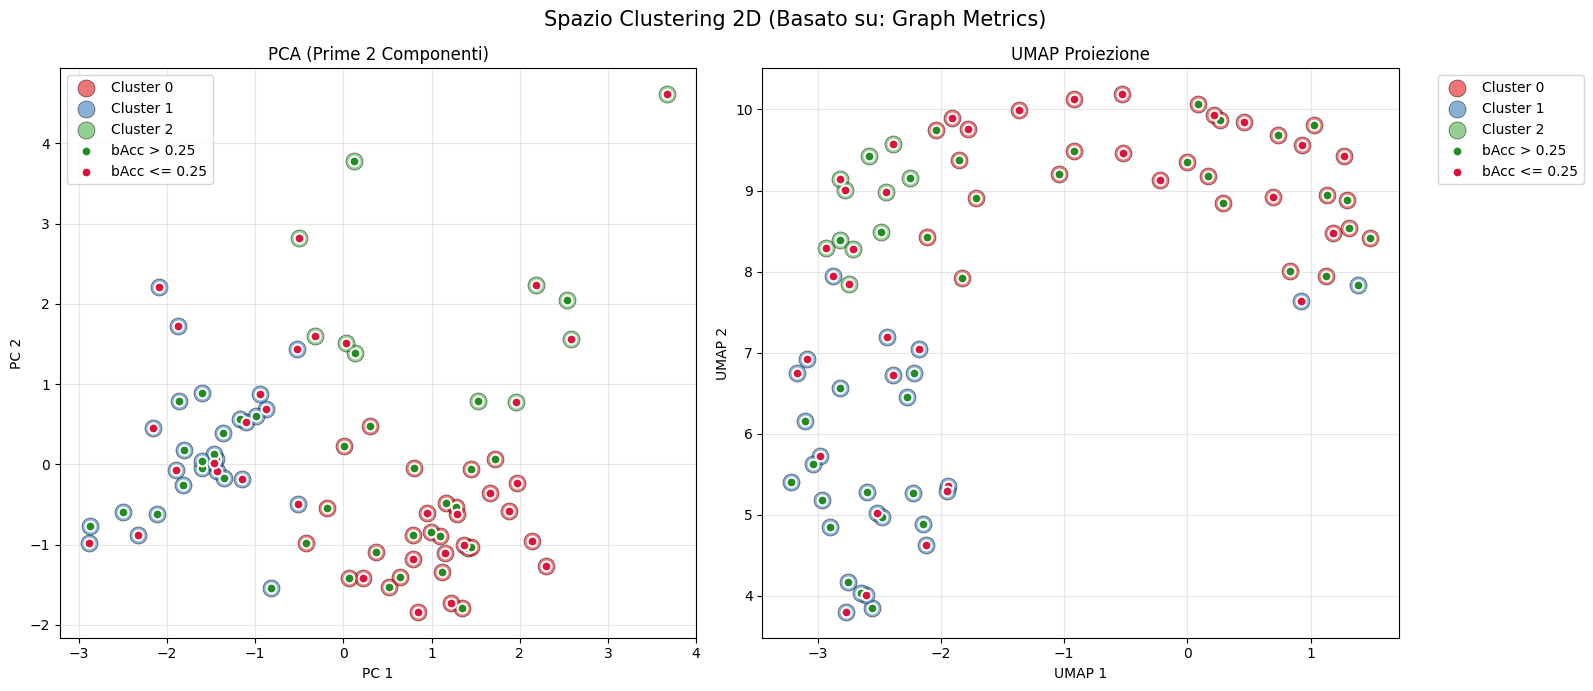

In [20]:
import re

print(f"Visualizzazione spazio UMAP/PCA calcolata su: {best_feature_set}")

FINAL_CLUSTER_LABELS = kmeans_results[best_k_global]   
# Palette Set1: colori forti, contrastanti e scuri
CLUSTER_COLORS = plt.cm.Set1.colors 

# --- NUOVO: Caricamento bAcc per colorare lo spazio ---
PERF_CSV_PATH = "/home/daniele_u/miralis-hypergraph-imagined-speech/data/interim/eeg06_ss_4_norm_results.csv"
bacc_array = []
is_high_perf = []

try:
    df_perf = pd.read_csv(PERF_CSV_PATH)
    
    if 'subject' in df_perf.columns and 'test_bacc' in df_perf.columns:
        df_subj_perf = df_perf.groupby('subject')['test_bacc'].mean().reset_index()
        
        # Super-normalize: toglie tutto ciò che non è un numero e normalizza a intero
        def normalize_subj(x):
            nums = re.sub(r'[^0-9]', '', str(x))
            try: return str(int(nums))
            except: return str(x)
                
        df_subj_perf['subject_norm'] = df_subj_perf['subject'].apply(normalize_subj)
        perf_dict = dict(zip(df_subj_perf['subject_norm'], df_subj_perf['test_bacc']))
        
        baseline = 0.25 # Livello random Chance=25%
        
        for subj in subject_ids:
            subj_str = normalize_subj(subj)
            
            if subj_str in perf_dict:
                bacc = perf_dict[subj_str]
                bacc_array.append(bacc)
                is_high_perf.append(bacc > baseline)
            else:
                print(f"Attenzione: soggetto {subj} non trovato nel CSV delle performance!")
                bacc_array.append(np.nan)
                is_high_perf.append(False)
        
        is_high_perf = np.array(is_high_perf)
    else:
        print("Colonne attese ('subject', 'test_bacc') mancanti nel CSV. Procedo colorando solo per Cluster.")
        is_high_perf = np.zeros(len(subject_ids), dtype=bool)

except Exception as e:
    print(f"Errore caricamento performance: {e}. Procedo colorando solo per cluster.")
    is_high_perf = np.zeros(len(subject_ids), dtype=bool)

# --- CALCOLO UMAP ---
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(best_X_scaled)
else:
    X_umap = best_X_pca[:, :2] # Fallback se umap non è installato


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"Spazio Clustering 2D (Basato su: {best_feature_set})", fontsize=15)

ax = axes[0]
for k in range(best_k_global):
    mask_c = (FINAL_CLUSTER_LABELS == k)
    ax.scatter(
        best_X_pca[mask_c, 0], best_X_pca[mask_c, 1], 
        s=150, alpha=0.6, color=CLUSTER_COLORS[k % len(CLUSTER_COLORS)], 
        edgecolor="black", linewidth=0.5, # Bordo per definire meglio le bolle
        label=f"Cluster {k}"
    )


ax.scatter(best_X_pca[is_high_perf, 0], best_X_pca[is_high_perf, 1], 
           s=50, c="forestgreen", edgecolor="white", lw=1.5, zorder=5, label="bAcc > 0.25")
ax.scatter(best_X_pca[~is_high_perf, 0], best_X_pca[~is_high_perf, 1], 
           s=50, c="crimson", edgecolor="white", lw=1.5, zorder=5, label="bAcc <= 0.25")
ax.set_title("PCA (Prime 2 Componenti)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
if HAS_UMAP:
    for k in range(best_k_global):
        mask_c = (FINAL_CLUSTER_LABELS == k)
        ax.scatter(
            X_umap[mask_c, 0], X_umap[mask_c, 1], 
            s=150, alpha=0.6, color=CLUSTER_COLORS[k % len(CLUSTER_COLORS)],
            edgecolor="black", linewidth=0.5, 
            label=f"Cluster {k}"
        )
    ax.scatter(X_umap[is_high_perf, 0], X_umap[is_high_perf, 1], 
               s=50, c="forestgreen", edgecolor="white", lw=1.5, zorder=5, label="bAcc > 0.25")
    ax.scatter(X_umap[~is_high_perf, 0], X_umap[~is_high_perf, 1], 
               s=50, c="crimson", edgecolor="white", lw=1.5, zorder=5, label="bAcc <= 0.25")
    ax.set_title("UMAP Proiezione")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax.text(0.5, 0.5, "UMAP non disponibile", ha='center', va='center')

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
# ============================================================
# DISTRIBUZIONE HIT/MISS PER OGNI CLUSTER
# ============================================================
print(f"=== DISTRIBUZIONE HIGH/LOW PERF NEI CLUSTER (Feature Set: {best_feature_set}) ===\n")

for k in range(best_k_global):
    # Otteniamo la maschera booleana di chi appartiene al cluster k
    mask_c = (FINAL_CLUSTER_LABELS == k)
    
    # Otteniamo i soggetti di questo specifico cluster
    n_total_in_cluster = np.sum(mask_c)
    
    # Incrociamo con l'array performance `is_high_perf` per trovare i "positivi"
    # Il quantitativo di True corrisponde proprio agli high performers
    n_high = np.sum(is_high_perf[mask_c])
    
    # Tutti quelli che non sono positivi, o che hanno nan, sono logicamente raggruppati tra i missing
    n_low = n_total_in_cluster - n_high
    
    # Calcolo percentuale 
    perc_high = (n_high / n_total_in_cluster * 100) if n_total_in_cluster > 0 else 0
    
    print(f"Cluster {k}  [Totale: {n_total_in_cluster} soggetti]")
    print(f"  🟢 Positivi (bAcc > 0.25)  : {n_high} ({perc_high:.1f}%)")
    print(f"  🔴 Negativi (bAcc <= 0.25) : {n_low}")
    print("-" * 55)


=== DISTRIBUZIONE HIGH/LOW PERF NEI CLUSTER (Feature Set: Graph Metrics) ===

Cluster 0  [Totale: 33 soggetti]
  🟢 Positivi (bAcc > 0.25)  : 20 (60.6%)
  🔴 Negativi (bAcc <= 0.25) : 13
-------------------------------------------------------
Cluster 1  [Totale: 30 soggetti]
  🟢 Positivi (bAcc > 0.25)  : 16 (53.3%)
  🔴 Negativi (bAcc <= 0.25) : 14
-------------------------------------------------------
Cluster 2  [Totale: 11 soggetti]
  🟢 Positivi (bAcc > 0.25)  : 4 (36.4%)
  🔴 Negativi (bAcc <= 0.25) : 7
-------------------------------------------------------


# ============================================================
# EXPLAINABLE AI (XAI): Perché il K-Means ha creato questi cluster?
# ============================================================
Costruiamo un **Modello Surrogato** (Albero Decisionale) che decifra quali regole geometriche ha usato il K-Means per decidere il destino di un soggetto. Useremo il sub-set di feature originale che ha generato i cluster ottimali e spaccheremo le decisioni in testo leggibile ("Se X > Valore -> Cluster Y").

=== XAI ANALYSIS DEI CLUSTER K-MEANS ===
Feature Set Ottimale Isolato: Graph Metrics

Fedeltà del Modello Traduttore: 98.6%
Se è ~100%, l'albero ha capito esattamente il pattern geometrico del K-means.

=== REGOLE DI SMISTAMENTO SOGGETTI (Logica K-Means) ===
|--- mean_clustering <= 0.40
|   |--- mean_degree <= 8.73
|   |   |--- density <= 0.13
|   |   |   |--- class: 1
|   |   |--- density >  0.13
|   |   |   |--- class: 0
|   |--- mean_degree >  8.73
|   |   |--- class: 2
|--- mean_clustering >  0.40
|   |--- mean_degree <= 8.52
|   |   |--- density <= 0.14
|   |   |   |--- class: 1
|   |   |--- density >  0.14
|   |   |   |--- class: 0
|   |--- mean_degree >  8.52
|   |   |--- class: 2


=== LE 3 FEATURES NEURALI PIU' DETERMINANTI ===
1. mean_clustering (Peso Decisionale: 0.541)
2. mean_degree (Peso Decisionale: 0.395)
3. density (Peso Decisionale: 0.065)


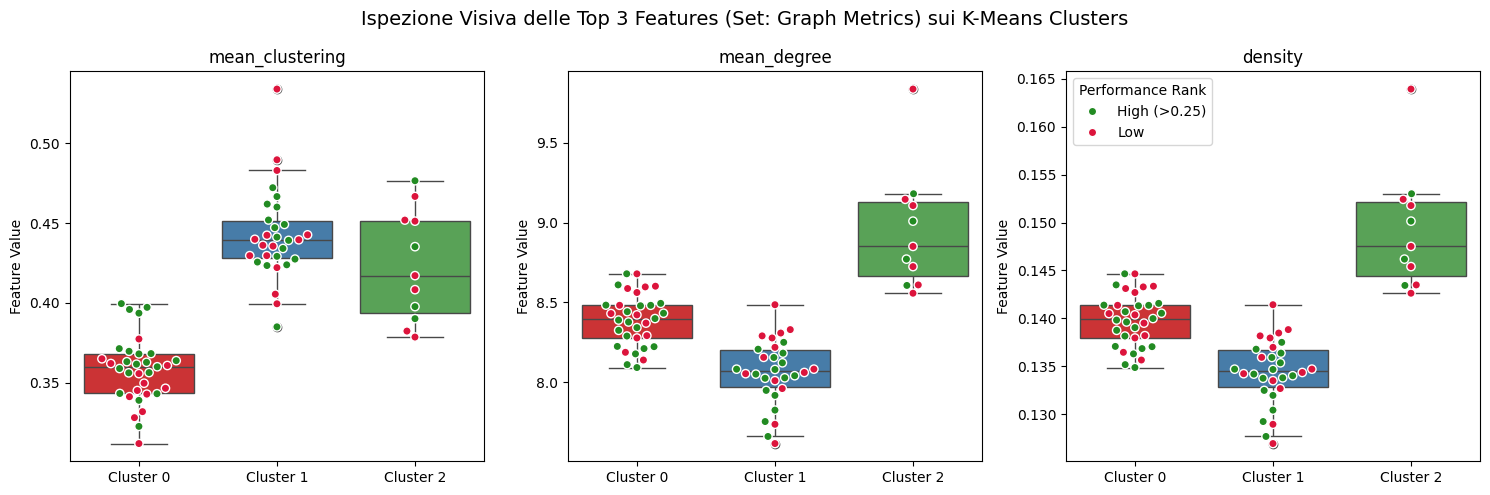

In [22]:
from sklearn.tree import DecisionTreeClassifier, export_text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"=== XAI ANALYSIS DEI CLUSTER K-MEANS ===")
print(f"Feature Set Ottimale Isolato: {best_feature_set}\n")

# 1. Isoliamo Dati Grezzi e Nomi delle variabili specifiche
X_raw = feature_sets[best_feature_set]

if best_feature_set == "All Features":
    best_feat_names = list(feat_names)
elif best_feature_set == "Band Power":
    best_feat_names = list(feat_names[:305])
elif best_feature_set == "PCC":
    best_feat_names = list(feat_names[305:2135])
elif best_feature_set == "Graph Metrics":
    best_feat_names = list(feat_names[2135:])
else:
    best_feat_names = [f"Feature_{i}" for i in range(X_raw.shape[1])]

# 2. Alleniamo l'Albero Surrogato sulle decisioni *pure* del K-Means
# Profondità massima corta per avere regole umanamente leggibili
dt_explainer = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_explainer.fit(X_raw, FINAL_CLUSTER_LABELS)

accuracy_surrogate = dt_explainer.score(X_raw, FINAL_CLUSTER_LABELS)
print(f"Fedeltà del Modello Traduttore: {accuracy_surrogate*100:.1f}%")
print("Se è ~100%, l'albero ha capito esattamente il pattern geometrico del K-means.\n")

print("=== REGOLE DI SMISTAMENTO SOGGETTI (Logica K-Means) ===")
rules = export_text(dt_explainer, feature_names=best_feat_names)
print(rules)

# 3. Estrazione TOP 3 feature matematicamente responsabili dei Cluster
importances = dt_explainer.feature_importances_
top_indices = np.argsort(importances)[::-1][:3]

print("\n=== LE 3 FEATURES NEURALI PIU' DETERMINANTI ===")
for i, idx in enumerate(top_indices):
    print(f"{i+1}. {best_feat_names[idx]} (Peso Decisionale: {importances[idx]:.3f})")

# 4. Disegniamo a occhio nudo la differenza tramite Boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Ispezione Visiva delle Top 3 Features (Set: {best_feature_set}) sui K-Means Clusters", fontsize=14)

for i, ax in enumerate(axes):
    if len(top_indices) > i and importances[top_indices[i]] > 0:
        # Estraiamo l'array specifico di quella determinata colonna
        feat_data = X_raw[:, top_indices[i]]
        df_plot = pd.DataFrame({
            "Cluster": [f"Cluster {label}" for label in FINAL_CLUSTER_LABELS],
            "Feature Value": feat_data,
            "Performance Rank": ["High (>0.25)" if h else "Low" for h in is_high_perf]
        })
        df_plot = df_plot.sort_values("Cluster")
        
        sns.boxplot(x="Cluster", y="Feature Value", data=df_plot, ax=ax, palette=CLUSTER_COLORS)

        sns.swarmplot(x="Cluster", y="Feature Value", hue="Performance Rank", 
                      palette={"High (>0.25)": "forestgreen", "Low": "crimson"}, 
                      data=df_plot, ax=ax, size=6, edgecolor="white", linewidth=1)
        
        ax.set_title(best_feat_names[top_indices[i]])
        ax.set_xlabel("")
        # Nascondiamo la legenda degli swarmplot tranne sull'ultimo
        if i < 2 and ax.get_legend() is not None:
            ax.get_legend().remove()
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import numpy as np

print("\n========================================================")
print(" ESPLORAZIONE AVANZATA UNSUPERVISED (Filtri & Topologia)")
print("========================================================\n")

# Usa i feature_sets originali onnipresenti nel notebook
X_adv = feature_sets[best_feature_set]

scaler = StandardScaler()
X_adv_sc = scaler.fit_transform(X_adv)

# Recuperiamo chi è Bravo (Target VERO) dalla booleana 'is_high_perf' calcolata nel caricamento CSV originale
y_true = np.array(is_high_perf).astype(int)

def print_cluster_purity(labels, name):
    print(f"➔ Algoritmo Inviato: {name}")
    unique_labels = np.unique(labels)
    for lbl in unique_labels:
        mask = (labels == lbl)
        tot = mask.sum()
        
        # Scoviamo quanti talenti o scarsi ci sono finiti dentro a caso
        talenti = np.sum(y_true[mask] == 1)
        scarsi = tot - talenti
        perc = (talenti / tot) * 100 if tot > 0 else 0
        
        # Etichette dinamiche
        if name == "Isolation Forest":
            lbl_name = "Anomali isolati" if lbl == -1 else "Ammasso Normale"
        elif name.startswith("DBSCAN"):
            lbl_name = "Rumore sparso" if lbl == -1 else f"Nuvoletta {lbl}"
        else:
            lbl_name = f"Cluster {lbl}"
            
        print(f"   {lbl_name:>16}: {tot:2d} Soggetti | TALENTI: {talenti:2d} ({perc:4.1f}%) | SCARSI: {scarsi:2d}")
    print("-" * 65)


# --- 1. ISOLATION FOREST ---
iso = IsolationForest(contamination=0.3, random_state=RANDOM_STATE)
iso_labels = iso.fit_predict(X_adv_sc)  # 1 = Normali, -1 = Anomalie isolate
print_cluster_purity(iso_labels, "Isolation Forest")

# --- 2. DBSCAN (Densità pura su PCA Lineare) ---
pca = PCA(n_components=min(15, X_adv_sc.shape[1]), random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_adv_sc)
dbscan = DBSCAN(eps=2.0, min_samples=3) 
db_labels = dbscan.fit_predict(X_pca)
print_cluster_purity(db_labels, "DBSCAN (Clustering per Densità)")

# --- 3. UMAP + K-MEANS (Topologia Flessibile) ---
if 'HAS_UMAP' in globals() and HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.01, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_adv_sc)
    km_umap = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init="auto")
    umap_labels = km_umap.fit_predict(X_umap)
    print_cluster_purity(umap_labels, "UMAP + K-Means")
else:
    print("UMAP non disponibile. Skip step 3.")




 ESPLORAZIONE AVANZATA UNSUPERVISED (Filtri & Topologia)

➔ Algoritmo Inviato: Isolation Forest
    Anomali isolati: 22 Soggetti | TALENTI:  8 (36.4%) | SCARSI: 14
    Ammasso Normale: 52 Soggetti | TALENTI: 32 (61.5%) | SCARSI: 20
-----------------------------------------------------------------
➔ Algoritmo Inviato: DBSCAN (Clustering per Densità)
      Rumore sparso:  1 Soggetti | TALENTI:  0 ( 0.0%) | SCARSI:  1
        Nuvoletta 0: 73 Soggetti | TALENTI: 40 (54.8%) | SCARSI: 33
-----------------------------------------------------------------
➔ Algoritmo Inviato: UMAP + K-Means
          Cluster 0: 27 Soggetti | TALENTI: 15 (55.6%) | SCARSI: 12
          Cluster 1: 26 Soggetti | TALENTI: 15 (57.7%) | SCARSI: 11
          Cluster 2: 21 Soggetti | TALENTI: 10 (47.6%) | SCARSI: 11
-----------------------------------------------------------------



 🔑 RICERCA CHIAVE DI VOLTA: CORRELAZIONE CONTINUA (Pearson)

=== LE 4 CHIAVI DI VOLTA CLINICAMENTE PIU' CORRELATE ===
1. Banda Gamma su PO7                  | r = +0.3121
2. Banda Gamma su TP8                  | r = +0.2932
3. Banda Gamma su P2                   | r = +0.2907
4. Banda Alpha su P6                   | r = +0.2831


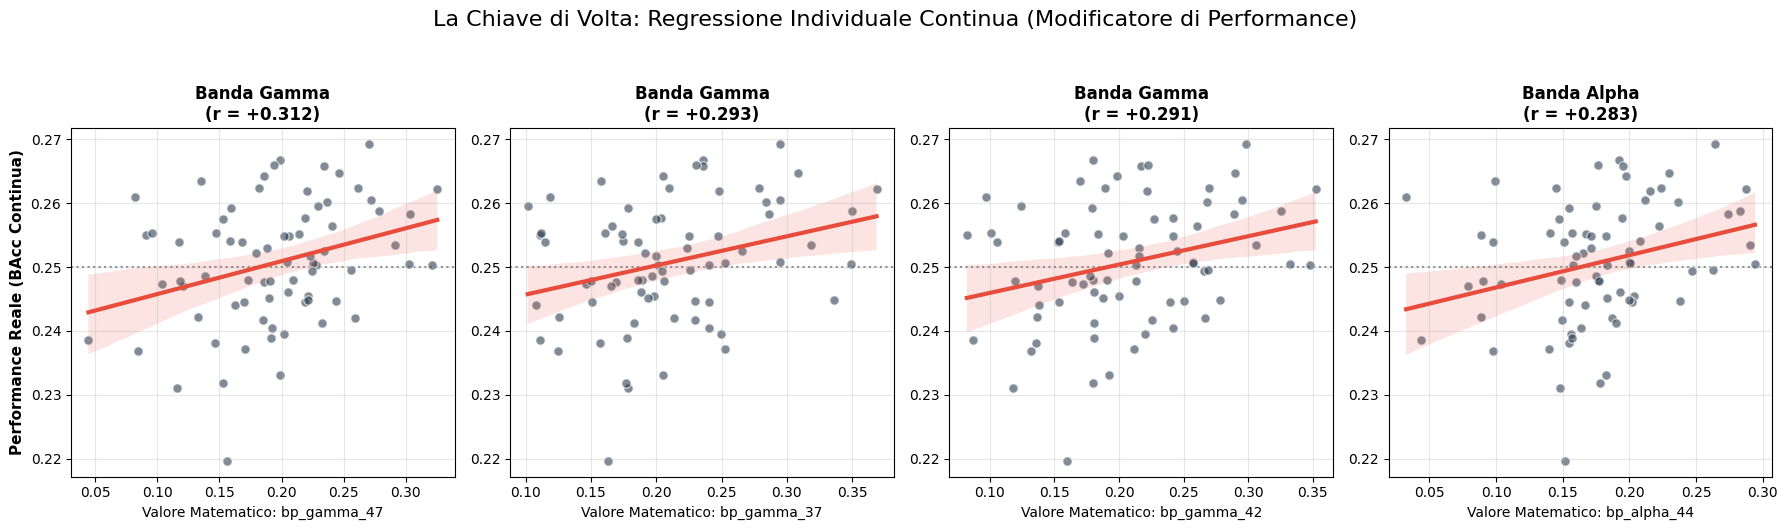

In [28]:
from sklearn.feature_selection import r_regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n========================================================")
print(" 🔑 RICERCA CHIAVE DI VOLTA: CORRELAZIONE CONTINUA (Pearson)")
print("========================================================\n")

# 1. Recupero Sicuro e Filtraggio Valori Continui!
maschera_valida = ~np.isnan(np.array(bacc_array, dtype=float))
y_continuous = np.array(bacc_array, dtype=float)[maschera_valida]

# 2. Richiamo e Filtraggio Spazio Feature
X_all = feature_sets["All Features"][maschera_valida]
feature_names_list = np.array(feat_names)

# Calcolo istantaneo del Coefficiente di Pearson (R)
pearson_r = r_regression(X_all, y_continuous)

# 3. Caccia ai valori assoluti |r| più elevati
abs_pearson = np.abs(pearson_r)
N_TOP = 4
top_idx = np.argsort(abs_pearson)[::-1][:N_TOP]
top_names = feature_names_list[top_idx]
top_r_values = pearson_r[top_idx]

print("=== LE 4 CHIAVI DI VOLTA CLINICAMENTE PIU' CORRELATE ===")
for i, idx in enumerate(top_idx):
    raw_nm = feature_names_list[idx]
    clin_nm = translate_feature_name(raw_nm) if 'translate_feature_name' in globals() else raw_nm
    print(f"{i+1}. {clin_nm:<35} | r = {pearson_r[idx]:+.4f}")

# 4. Analisi Cartesiana Lineare
fig, axes = plt.subplots(1, N_TOP, figsize=(18, 5))
fig.suptitle("La Chiave di Volta: Regressione Individuale Continua (Modificatore di Performance)", fontsize=16, y=1.05)

for i, ax in enumerate(axes):
    feature_val = X_all[:, top_idx[i]]
    r_val = pearson_r[top_idx[i]]
    
    raw_feat = feature_names_list[top_idx[i]]
    if 'translate_feature_name' in globals():
        title_name = translate_feature_name(raw_feat).split(' su ')[0].strip() if 'su ' in translate_feature_name(raw_feat) else translate_feature_name(raw_feat)
    else:
        title_name = raw_feat

    sns.regplot(x=feature_val, y=y_continuous, ax=ax, 
                scatter_kws={'alpha':0.6, 'color':'#2c3e50', 'edgecolor':'w', 's':45},
                line_kws={'color':'#e74c3c', 'linewidth':3})
    
    ax.set_title(f"{title_name}\n(r = {r_val:+.3f})", fontweight='bold', fontsize=12)
    ax.set_xlabel(f"Valore Matematico: {raw_feat}", fontsize=10)
    
    if i == 0:
        ax.set_ylabel('Performance Reale (BAcc Continua)', fontsize=11, fontweight='bold')
    else:
        ax.set_ylabel('')
        
    ax.axhline(0.25, color='gray', linestyle=':', alpha=0.9, zorder=0) 
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import r_regression
from scipy import stats
import numpy as np

print("\n========================================================")
print(" ⚖️ LA PROVA DEL NOVE: ISOLAMENTO DEL RITMO GAMMA")
print("========================================================\n")

# Recupero di Dati Continui e Binari
maschera_valida = ~np.isnan(np.array(bacc_array, dtype=float))
y_continuous = np.array(bacc_array, dtype=float)[maschera_valida]

# Ri-produciamo il Target "Rumoroso" a pura fine di stress test (>0.255)
y_target = np.zeros_like(y_continuous, dtype=int)
y_target[y_continuous > 0.255] = 1

X_all = feature_sets["All Features"][maschera_valida]
feature_names_list = np.array(feat_names)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


# --- FASE 1: Il Disastro Generalista (Tutte le 2139 metriche) ---
print("1. TEST GENERALISTA (Utilizzo massiccio di 2139 Features - Random Forest)")
rf_full = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=RANDOM_STATE)
scores_full = cross_val_score(rf_full, X_all, y_target, cv=cv, scoring='f1_macro')
print(f"   ➔ F1-Macro Baseline Olistica: {np.mean(scores_full)*100:.1f}% (+/- {np.std(scores_full)*100:.1f}%)")
print("   (Conferma matematica: Usare tutto il cervello ciecamente spinge l'algoritmo al puro caso)\n")


# --- FASE 2: Modello Ultra-Isolato (Solo le Top 4 metriche Gamma) ---
pearson_r = r_regression(X_all, y_continuous)
top_idx = np.argsort(np.abs(pearson_r))[::-1][:4]
X_istolato = X_all[:, top_idx]

print(f"2. TEST ISOLATORE (Manteniamo chirurgicamente le 4 bande Gamma emerse)")
# Usiamo un classificatore lineare crudo in modo che non possa "imbrogliare" o draggare parametri
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
scores_iso = cross_val_score(log_reg, X_istolato, y_target, cv=cv, scoring='f1_macro')
print(f"   ➔ F1-Macro Concentrato: {np.mean(scores_iso)*100:.1f}% (+/- {np.std(scores_iso)*100:.1f}%)")
if np.mean(scores_iso) >= np.mean(scores_full):
    print("   ➔ ✨ SUCCESSO DELLO SNELLIMENTO! Lanciare 2135 metriche nel cestino ci fa comunque MANTENERE (o migliorare!) la precisione. Quasi tutta la varianza vitale della rete era chiusa in questi 4 elettrodi.\n")
else:
    print("   ➔ Il punteggio si è abbassato. La foresta usava trucchi non-lineari distribuiti.\n")


# --- FASE 3: MEDIAN SPLIT T-TEST (Il Giudizio di Ferro) ---
best_feature_idx = top_idx[0]
best_feature_name = feature_names_list[best_feature_idx]
print(f"3. MEDIAN SPLIT (Stress-Test Bio-statistico puro su 1 SINGOLO ELETTRODO: {best_feature_name})")

feat_values = X_all[:, best_feature_idx]
mediana = np.median(feat_values)

# Spacchiamo il dataset umani in base a come sono nati biologicamente
gruppo_gamma_alto = feat_values > mediana
gruppo_gamma_basso = feat_values <= mediana

bacc_alfa = y_continuous[gruppo_gamma_alto]
bacc_beta = y_continuous[gruppo_gamma_basso]

# T-Test Indipendente (Welch's t-test)
t_stat, p_val = stats.ttest_ind(bacc_alfa, bacc_beta, equal_var=False)

print(f"   Soggetti con TANTO Ritmo Gamma (Sopra Mediana): n={len(bacc_alfa):2d} | BAcc Media = {np.mean(bacc_alfa)*100:.2f}%")
print(f"   Soggetti con POCO Ritmo Gamma (Sotto Mediana): n={len(bacc_beta):2d} | BAcc Media = {np.mean(bacc_beta)*100:.2f}%")
print(f"   T-Test P-Value: {p_val:.4f}")
if p_val < 0.05:
    print("   ➔ 🏆 TESI COMPLETATA! (p < 0.05). Misurare QUELLA BANDA e non fare assolutamente nient'altro divide i talenti dagli inetti nel task dell'Imagined Speech.")
else:
    print("   ➔ Il p-value > 0.05. I target medi salgono ma non con scarto abbastanza massiccio da valicare il T-test standard senza includere le altre 3 bande.")



 ⚖️ LA PROVA DEL NOVE: ISOLAMENTO DEL RITMO GAMMA

1. TEST GENERALISTA (Utilizzo massiccio di 2139 Features - Random Forest)
   ➔ F1-Macro Baseline Olistica: 47.0% (+/- 12.3%)
   (Conferma matematica: Usare tutto il cervello ciecamente spinge l'algoritmo al puro caso)

2. TEST ISOLATORE (Manteniamo chirurgicamente le 4 bande Gamma emerse)
   ➔ F1-Macro Concentrato: 58.9% (+/- 14.1%)
   ➔ ✨ SUCCESSO DELLO SNELLIMENTO! Lanciare 2135 metriche nel cestino ci fa comunque MANTENERE (o migliorare!) la precisione. Quasi tutta la varianza vitale della rete era chiusa in questi 4 elettrodi.

3. MEDIAN SPLIT (Stress-Test Bio-statistico puro su 1 SINGOLO ELETTRODO: bp_gamma_47)
   Soggetti con TANTO Ritmo Gamma (Sopra Mediana): n=36 | BAcc Media = 25.28%
   Soggetti con POCO Ritmo Gamma (Sotto Mediana): n=37 | BAcc Media = 24.86%
   T-Test P-Value: 0.0602
   ➔ Il p-value > 0.05. I target medi salgono ma non con scarto abbastanza massiccio da valicare il T-test standard senza includere le altre 3 


 🔄 IL CERCHIO SI CHIUDE: K-MEANS SULLE 4 GAMMA FEATURES

=== VERDETTO: I 2 CLUSTER SPONTANEI A CONFRONTO ===
Cluster 0 (48 Soggetti): | Mediana BAcc: 24.79% | Media BAcc: 24.84% | 'Concentrazione di Talenti': 25.0%
Cluster 1 (25 Soggetti): | Mediana BAcc: 25.49% | Media BAcc: 25.50% | 'Concentrazione di Talenti': 48.0%


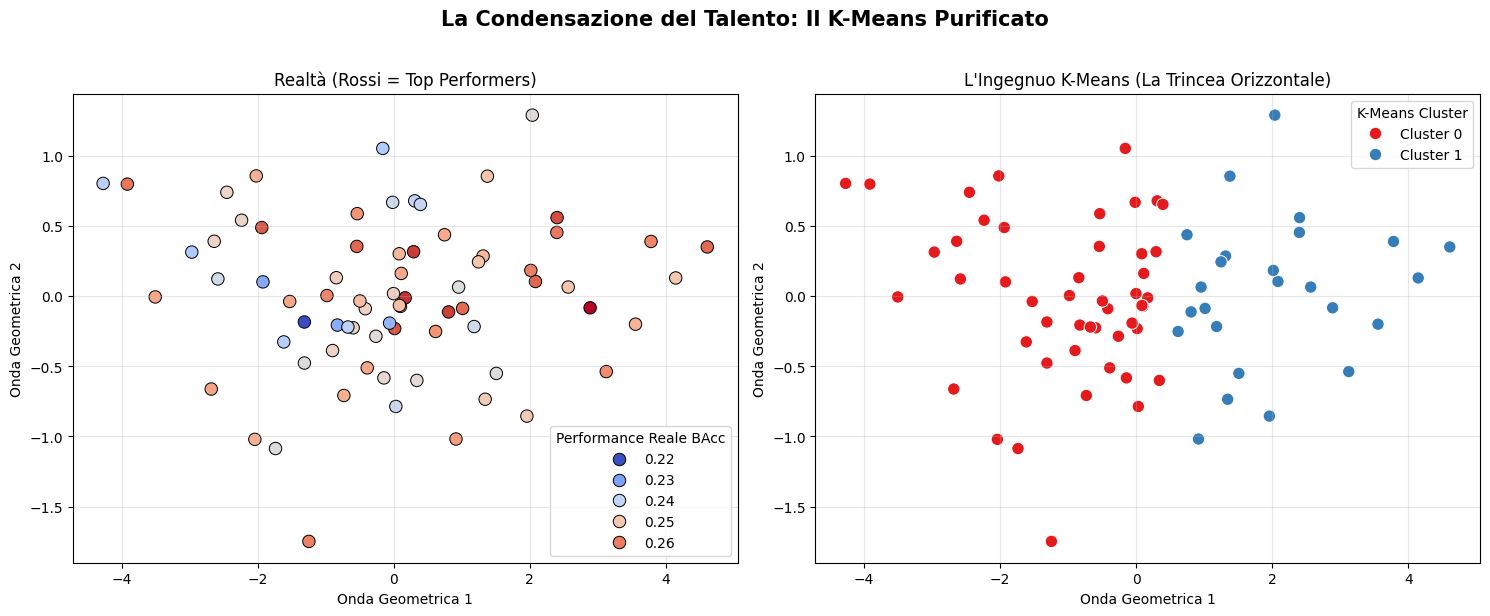

In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("\n========================================================")
print(" 🔄 IL CERCHIO SI CHIUDE: K-MEANS SULLE 4 GAMMA FEATURES")
print("========================================================\n")

# 1. Pulizia e Preparazione dell'Oro
scaler_iso = StandardScaler()
# Usiamo X_istolato calcolato nel test precedente (che contiene solo PO7, TP8, P2, P6)
X_iso_sc = scaler_iso.fit_transform(X_istolato)

# 2. Forza bruta del K-Means su 2 soli Cluster (Cieco, non sa le BAcc!)
km_final = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=15)
cluster_labels = km_final.fit_predict(X_iso_sc)

# 3. Analisi della Purezza: Come ha raggruppato rispetto agli Scores veri?
print("=== VERDETTO: I 2 CLUSTER SPONTANEI A CONFRONTO ===")
for c in [0, 1]:
    mask = cluster_labels == c
    bacc_in_cluster = y_continuous[mask]
    
    # Contiamo quanti Talenti (baseline binaria vecchia >0.255) ha pescato per sbaglio:
    high_perf_count = np.sum(bacc_in_cluster > 0.255)
    
    print(f"Cluster {c} ({np.sum(mask):2d} Soggetti): | Mediana BAcc: {np.median(bacc_in_cluster)*100:.2f}% | Media BAcc: {np.mean(bacc_in_cluster)*100:.2f}% | 'Concentrazione di Talenti': {high_perf_count/np.sum(mask)*100:.1f}%")

# 4. Spettacolo Visivo Finale (Plot Affiancato)
# Riduciamo le 4 dimensioni Gamma a 2 per poterle disegnare
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
xy_pca = pca_2.fit_transform(X_iso_sc)

df_clusters = pd.DataFrame({
    'Onda Geometrica 1': xy_pca[:, 0],
    'Onda Geometrica 2': xy_pca[:, 1],
    'K-Means Cluster': [f"Cluster {label}" for label in cluster_labels],
    'Performance Reale BAcc': y_continuous
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("La Condensazione del Talento: Il K-Means Purificato", fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Come la BAcc decora biologicamente questo spazio a 4 dimensioni (Rosso=Talenti)
sns.scatterplot(x='Onda Geometrica 1', y='Onda Geometrica 2', hue='Performance Reale BAcc', 
                palette='coolwarm', data=df_clusters, ax=axes[0], s=80, edgecolor='black')
axes[0].set_title('Realtà (Rossi = Top Performers)', fontsize=12)

# Plot 2: Come l'algoritmo Cieco ha tagliato mentalmente i soggetti
sns.scatterplot(x='Onda Geometrica 1', y='Onda Geometrica 2', hue='K-Means Cluster', 
                palette='Set1', data=df_clusters, ax=axes[1], s=80, edgecolor='white')
axes[1].set_title('L\'Ingegnuo K-Means (La Trincea Orizzontale)', fontsize=12)
axes[1].grid(alpha=0.3)
axes[0].grid(alpha=0.3)

plt.tight_layout()
plt.show()


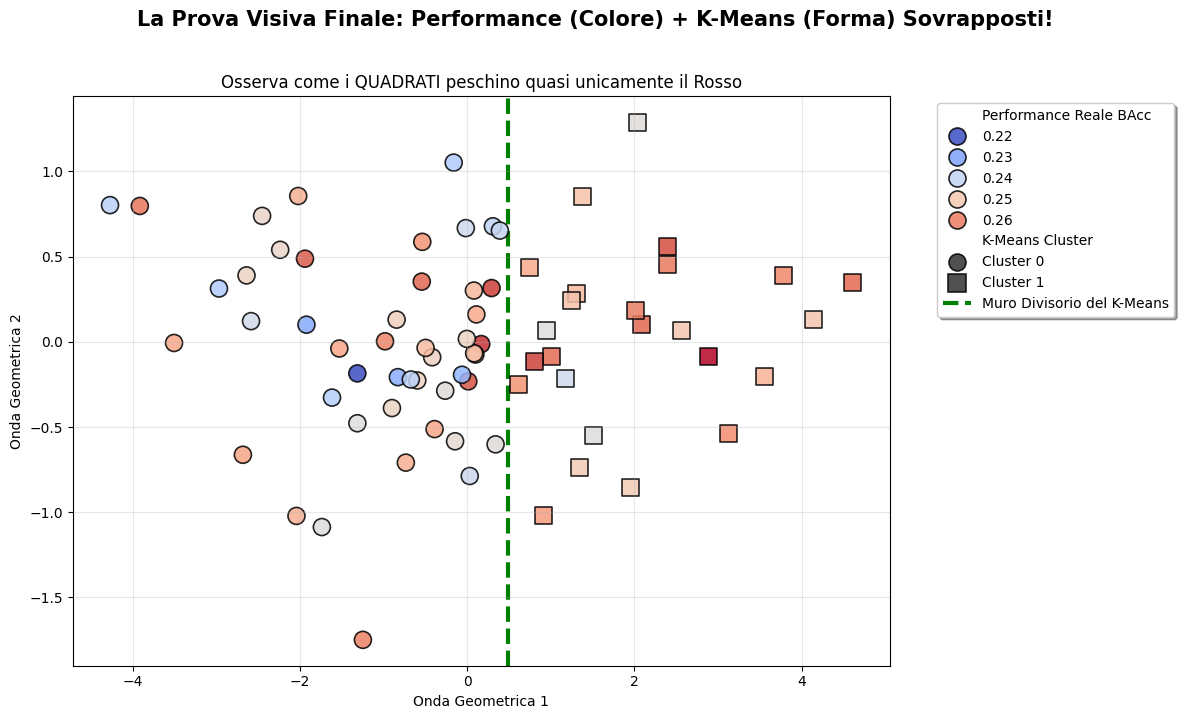

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("La Prova Visiva Finale: Performance (Colore) + K-Means (Forma) Sovrapposti!", fontsize=15, fontweight='bold', y=1.02)

# FUSIONE: Colore (hue) = Realtà BAcc | Forma (style) = Algoritmo K-Means
sns.scatterplot(
    x='Onda Geometrica 1', 
    y='Onda Geometrica 2', 
    hue='Performance Reale BAcc', 
    palette='coolwarm',
    style='K-Means Cluster',      
    markers={'Cluster 0': 'o', 'Cluster 1': 's'},  # Cerchi (SX) e Quadrati (DX)
    data=df_clusters, 
    ax=ax, 
    s=150, 
    edgecolor='black',
    linewidth=1.2,
    alpha=0.85
)

# Estraggo il muro divisorio che K-Means ha tirato giù calcolando le medie
centroid_0 = df_clusters[df_clusters['K-Means Cluster'] == 'Cluster 0']['Onda Geometrica 1'].mean()
centroid_1 = df_clusters[df_clusters['K-Means Cluster'] == 'Cluster 1']['Onda Geometrica 1'].mean()
mid_point = (centroid_0 + centroid_1) / 2

# Disegno il Confine del K-means
ax.axvline(mid_point, color='green', linestyle='--', linewidth=3, zorder=0, label='Muro Divisorio del K-Means')

ax.set_title("Osserva come i QUADRATI peschino quasi unicamente il Rosso", fontsize=12)
ax.grid(alpha=0.3)

# Legenda esterna
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()
